# Diabetes Transitional Care Resource Allocation System

**Final project:** I built a decision-support prototype for prioritizing post-discharge care for patients with diabetes.

**When care-management capacity is limited, which patients should receive extra transitional-care support first?**

Main workflow:

1. Clean and explore the UCI Diabetes 130-US Hospitals dataset.
2. Predict 30-day readmission risk with patient-level train/test splitting.
3. Rank patients into a capacity-limited worklist.
4. Estimate cost, savings, break-even points, and staffing impact.
5. Add RAG guidance from CMS/AHRQ discharge and readmission documents.
6. Compare the final tabular model with a fine-tuned prompt classifier.
7. Save the model artifacts for the Gradio/Hugging Face app.


## 1. Setup


In [37]:

import warnings
warnings.filterwarnings("ignore")

import csv
import json
import re
from pathlib import Path
import pickle

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_PLOTTING = True
except ImportError:
    plt = None
    HAS_PLOTTING = False
    print("matplotlib not installed; tables will run and plots will be skipped.")

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    sns = None
    HAS_SEABORN = False
    print("seaborn not installed; using matplotlib-only charts where possible.")

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)

RANDOM_STATE = 42


def find_project_root(marker_relpath=("data", "diabetic_data.csv")):
    """Walk upward from the current working directory to find the repo root -- the
    first directory containing data/diabetic_data.csv. This keeps the notebook portable
    across machines and however Jupyter was launched (repo root, a subfolder, etc.),
    instead of relying on one machine-specific hardcoded path.
    """
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / marker_relpath[0] / marker_relpath[1]).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find data/diabetic_data.csv by walking up from the current directory "
        f"({here}). Run this notebook from inside the uci-diabetes-readmission-project repo."
    )


PROJECT_DIR = find_project_root()
DATA_DIR = PROJECT_DIR / "data"
APP_DIR = PROJECT_DIR / "app"
ARTIFACT_DIR = APP_DIR / "artifacts"
PDF_DIR = APP_DIR / "pdfs"
DATA_PATH = DATA_DIR / "diabetic_data.csv"
MAPPING_PATH = DATA_DIR / "IDS_mapping.csv"
FINE_TUNED_PREDICTION_PATH = ARTIFACT_DIR / "fine_tuned_readmission_predictions.csv"
FINE_TUNED_MODEL_PATH = ARTIFACT_DIR / "fine_tuned_readmission_text_pipeline.pkl"
FINE_TUNED_COMPARISON_PATH = ARTIFACT_DIR / "fine_tuned_model_comparison.csv"

# Default scenario assumptions. These are editable, not measured financial facts.
DEFAULT_CAPACITY = 500
DEFAULT_THRESHOLD = 0.0  # ranking by top-N capacity is the main operating rule
DEFAULT_READMISSION_COST = 15_000
DEFAULT_INTERVENTION_COST = 300
DEFAULT_EFFECTIVENESS = 0.10

SMU_BLUE = "#354CA1"
SMU_RED = "#CC0035"
SMU_GRAY = "#6C6C6C"


def make_onehot_encoder(sparse=True):
    """Support both older and newer scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=sparse)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=sparse)


## 2. Load Data


In [38]:

df_raw = pd.read_csv(DATA_PATH)

print("Data path:", DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())


Data path: /Users/chloebarker/GitHub/uci-diabetes-readmission-project/data/diabetic_data.csv
Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Initial Data Understanding


Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Readmission target distribution:


,count,percent
readmitted,,
NO,54864,53.9
>30,35545,34.9
<30,11357,11.2


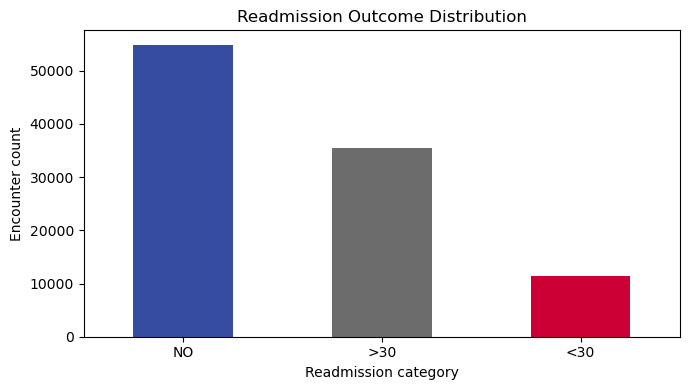

In [39]:
print("Columns:")
print(df_raw.columns.tolist())

print()
print("Readmission target distribution:")
readmission_counts = df_raw["readmitted"].value_counts()
readmission_order = ["NO", ">30", "<30"]
readmission_display = readmission_counts.reindex(readmission_order)
display(pd.DataFrame({
    "count": readmission_display,
    "percent": (readmission_display / len(df_raw) * 100).round(1)
}))

if HAS_PLOTTING:
    ax = readmission_display.plot(kind="bar", figsize=(7, 4), color=[SMU_BLUE, SMU_GRAY, SMU_RED])
    ax.set_title("Readmission Outcome Distribution")
    ax.set_xlabel("Readmission category")
    ax.set_ylabel("Encounter count")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Plot skipped because matplotlib is not installed.")


## 4. Cleaning and Feature Engineering

Key cleaning choices:

- Replace `?` with missing values.
- Map admission, discharge, and source IDs to readable categories.
- Exclude hospice/expired discharges because they do not fit a preventable-readmission intervention.
- Keep `encounter_id` and `patient_nbr` for audit/splitting, but exclude them from model features.
- Drop high-missingness fields and near-zero-variance medication fields.
- Encode age, medication activity, prior utilization, and ICD-9 diagnosis chapters.

Target:

- `1` = readmitted within 30 days (`<30`)
- `0` = not readmitted within 30 days (`NO` or `>30`)


In [40]:
def load_id_mappings(path):
    """Parse the UCI ID-mapping CSV, which stacks several small lookup tables in one file.

    Each section starts with a header row like ``admission_type_id,description`` and is
    followed by ``id, description`` rows until a blank line or the next section header.

    Returns
    -------
    dict[str, dict[int, str]]
        e.g. ``{"admission_type_id": {1: "Emergency", 2: "Urgent", ...}, ...}``
        Used below to turn opaque numeric codes into readable, stakeholder-facing labels.
    """
    mappings = {}
    current_section = None

    with open(path, newline="") as f:
        for row in csv.reader(f):
            if not row or not row[0].strip():
                continue

            first = row[0].strip()
            if first.endswith("_id"):
                current_section = first
                mappings[current_section] = {}
                continue

            if current_section is None:
                continue

            try:
                key = int(float(first))
            except ValueError:
                continue

            description = row[1].strip() if len(row) > 1 and row[1].strip() else "Unknown/not available"
            mappings[current_section][key] = description

    return mappings


ID_MAPPINGS = load_id_mappings(MAPPING_PATH)
for mapping_name, mapping_values in ID_MAPPINGS.items():
    print(f"{mapping_name}: {len(mapping_values)} mapped values")


def icd_chapter(code):
    """Collapse a raw ICD-9 diagnosis code into one of 19 broad clinical chapters.

    Individual ICD-9 codes are too sparse and high-cardinality to use directly as model
    features (thousands of distinct codes, many seen only once). Grouping into chapters
    (e.g. "Circulatory system", "Endocrine/metabolic") keeps the clinical signal that
    matters for readmission risk while giving the model enough examples per category to
    learn from. V- and E-codes (supplemental/external-cause codes) are mapped to their own
    chapters (18, 19); anything unparsable returns NaN and is treated as missing downstream.
    """
    if pd.isna(code):
        return np.nan

    code = str(code).strip()
    if code.startswith("V"):
        return 18
    if code.startswith("E"):
        return 19

    try:
        num = float(code)
    except ValueError:
        return np.nan

    if num < 140: return 1    # Infectious and parasitic diseases
    if num < 240: return 2    # Neoplasms
    if num < 280: return 3    # Endocrine, nutritional, metabolic, immunity
    if num < 290: return 4    # Blood diseases
    if num < 320: return 5    # Mental disorders
    if num < 390: return 6    # Nervous system and sense organs
    if num < 460: return 7    # Circulatory system
    if num < 520: return 8    # Respiratory system
    if num < 580: return 9    # Digestive system
    if num < 630: return 10   # Genitourinary system
    if num < 680: return 11   # Pregnancy/childbirth
    if num < 710: return 12   # Skin and subcutaneous tissue
    if num < 740: return 13   # Musculoskeletal system
    if num < 760: return 14   # Congenital anomalies
    if num < 780: return 15   # Perinatal period
    if num < 800: return 16   # Symptoms and ill-defined conditions
    if num < 1000: return 17  # Injury and poisoning
    return np.nan


def discharge_group(disposition_id):
    """Roll the ~30 raw discharge-disposition codes up into a small set of business-readable
    groups (e.g. "Home", "Skilled nursing facility"). This is the field a care manager would
    actually look at when deciding how complex a patient's post-discharge situation is."""
    groups = {
        1: "Home",
        6: "Home health",
        2: "Short-term hospital transfer",
        3: "Skilled nursing facility",
        4: "Intermediate care facility",
        5: "Other inpatient facility",
        7: "Left AMA",
        8: "Home IV provider",
        12: "Expected outpatient return",
        15: "Swing bed",
        16: "Outpatient referral",
        17: "Outpatient return",
        22: "Rehab facility",
        23: "Long-term care hospital",
        24: "Medicaid nursing facility",
        27: "Federal health care facility",
        28: "Psychiatric hospital",
        29: "Critical access hospital",
        30: "Other health care institution",
    }
    return groups.get(disposition_id, "Other/unknown")


def admission_type_group(admission_type_id):
    """Simplify the raw admission-type code into a business-readable label
    (e.g. "Emergency" vs. "Elective"), used for both display and modeling."""
    groups = {
        1: "Emergency",
        2: "Urgent",
        3: "Elective",
        4: "Newborn",
        5: "Not available",
        6: "Null",
        7: "Trauma center",
        8: "Not mapped",
    }
    return groups.get(admission_type_id, "Other/unknown")


def admission_source_group(source_id):
    """Bucket the raw admission-source code into a small number of business-meaningful
    categories (ER, referral, transfer, birth, unknown/other) rather than modeling dozens of
    granular source codes individually."""
    if source_id == 7:
        return "Emergency room"
    if source_id in [1, 2, 3]:
        return "Referral"
    if source_id in [4, 5, 6, 10, 18, 19, 22, 25, 26]:
        return "Transfer/continuing care"
    if source_id in [9, 15, 17, 20, 21]:
        return "Unknown/not available"
    if source_id in [11, 12, 13, 14, 23, 24]:
        return "Birth/newborn"
    return "Other"


def clean_diabetes_data(df, id_mappings):
    """Clean the raw UCI encounter table and engineer the features the model will use.

    This is the single place where every cleaning/feature-engineering *decision* for the
    project lives, so the rationale is documented right next to the code that implements it:

    1. Replace the dataset's ``"?"`` placeholder with a real missing value (``NaN``) so
       pandas/scikit-learn handle it correctly instead of treating it as a valid category.
    2. Drop hospice and expired discharge dispositions. A patient who died or entered
       hospice cannot benefit from a *readmission-prevention* intervention, so keeping them
       in the training population would teach the model on encounters outside the actual
       business decision.
    3. Map administrative ID codes (admission type/source, discharge disposition) to
       readable, grouped categories instead of using raw integer codes, which have no
       meaningful numeric order.
    4. Drop invalid/unknown gender rows (a small number of encounters) so the fairness
       checks in Section 12 compare only well-defined groups.
    5. Drop ``weight`` and ``payer_code`` (extremely high missingness) and any medication
       column where >99.9% of patients share the same value (near-zero variance, so the
       column can't meaningfully separate readmitted from non-readmitted patients).
    6. Keep ``encounter_id`` and ``patient_nbr`` for audit trails, worklists, and the
       patient-grouped train/test split, but exclude them from the model's feature matrix
       later (Section 7) so the model can't use them as spurious identifiers.
    7. Encode age as an ordinal decade and medication activity as an ordered scale
       (No < Steady < Down < Up), and group ICD-9 diagnosis codes into clinical chapters
       (see ``icd_chapter``).
    8. Engineer a handful of utilization/intensity features (prior visits, active
       medication count, tests/medications per day) that are common readmission-risk
       signals in the clinical literature.

    Returns
    -------
    (pandas.DataFrame, dict)
        The cleaned/engineered dataframe, and a small report dict used to print/display a
        summary of what was removed or dropped and why.
    """
    df = df.copy()
    starting_rows = len(df)
    df = df.replace("?", np.nan)

    missing_before = df.isna().mean().sort_values(ascending=False)

    # These encounters do not match the operational question of preventing a routine 30-day readmission.
    excluded_dispositions = [11, 13, 14, 19, 20, 21]
    df = df[~df["discharge_disposition_id"].isin(excluded_dispositions)].copy()

    df["admission_type_description"] = df["admission_type_id"].map(id_mappings["admission_type_id"])
    df["discharge_disposition_description"] = df["discharge_disposition_id"].map(id_mappings["discharge_disposition_id"])
    df["admission_source_description"] = df["admission_source_id"].map(id_mappings["admission_source_id"])
    df["discharge_group"] = df["discharge_disposition_id"].apply(discharge_group)
    df["admission_type_group"] = df["admission_type_id"].apply(admission_type_group)
    df["admission_source_group"] = df["admission_source_id"].apply(admission_source_group)

    df = df[df["gender"] != "Unknown/Invalid"].copy()

    high_missing_cols = ["weight", "payer_code"]

    medication_candidates = [
        "metformin", "repaglinide", "nateglinide", "chlorpropamide",
        "glimepiride", "acetohexamide", "glipizide", "glyburide",
        "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
        "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton",
        "insulin", "glyburide-metformin", "glipizide-metformin",
        "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
    ]
    near_zero_med_cols = []
    med_variance_rows = []
    for col in medication_candidates:
        if col not in df.columns:
            continue
        shares = df[col].value_counts(normalize=True, dropna=False)
        top_value = shares.index[0]
        top_share = float(shares.iloc[0])
        med_variance_rows.append({"column": col, "most_common_value": top_value, "most_common_share": top_share})
        if top_share >= 0.999:
            near_zero_med_cols.append(col)

    # Keep IDs for audit/worklists/splitting; do not use them as model predictors later.
    drop_cols = high_missing_cols + near_zero_med_cols + [
        "admission_type_id", "discharge_disposition_id", "admission_source_id"
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    for col in ["race", "medical_specialty", "max_glu_serum", "A1Cresult"]:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown")

    age_map = {
        "[0-10)": 0, "[10-20)": 1, "[20-30)": 2, "[30-40)": 3,
        "[40-50)": 4, "[50-60)": 5, "[60-70)": 6,
        "[70-80)": 7, "[80-90)": 8, "[90-100)": 9,
    }
    df["age_ordinal"] = df["age"].map(age_map)

    med_cols = [col for col in medication_candidates if col in df.columns]
    med_map = {"No": 0, "Steady": 1, "Down": 2, "Up": 3}
    for col in med_cols:
        df[col] = df[col].map(med_map)

    active_med_cols = [col for col in med_cols if col in df.columns]
    df["num_active_diabetes_meds"] = (df[active_med_cols].fillna(0) > 0).sum(axis=1)
    df["medication_change_flag"] = (df["change"] == "Ch").astype(int)
    df["total_prior_visits"] = df[["number_outpatient", "number_emergency", "number_inpatient"]].sum(axis=1)
    df["had_prior_utilization"] = (df["total_prior_visits"] > 0).astype(int)
    df["tests_per_day"] = df["num_lab_procedures"] / df["time_in_hospital"].clip(lower=1)
    df["medications_per_day"] = df["num_medications"] / df["time_in_hospital"].clip(lower=1)

    for diag_col in ["diag_1", "diag_2", "diag_3"]:
        df[f"{diag_col}_chapter"] = df[diag_col].apply(icd_chapter)
        df = df.drop(columns=[diag_col])

    df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

    cleaning_report = {
        "starting_rows": starting_rows,
        "ending_rows": len(df),
        "rows_removed_for_hospice_expired_or_invalid_gender": starting_rows - len(df),
        "dropped_high_missing_cols": high_missing_cols,
        "dropped_near_zero_medication_cols": near_zero_med_cols,
        "top_missing_before_cleaning": missing_before[missing_before > 0].head(10),
        "medication_variance_review": pd.DataFrame(med_variance_rows).sort_values("most_common_share", ascending=False),
    }

    return df, cleaning_report


df, cleaning_report = clean_diabetes_data(df_raw, ID_MAPPINGS)
print("Cleaned shape:", df.shape)
print("Rows removed:", cleaning_report["rows_removed_for_hospice_expired_or_invalid_gender"])
print("Dropped high-missing columns:", cleaning_report["dropped_high_missing_cols"])
print("Dropped near-zero-variance medication columns:", cleaning_report["dropped_near_zero_medication_cols"])

display(cleaning_report["top_missing_before_cleaning"].to_frame("missing_percent_before_cleaning").assign(
    missing_percent_before_cleaning=lambda x: (x["missing_percent_before_cleaning"] * 100).round(1)
))
display(cleaning_report["medication_variance_review"].head(12).round(4))
display(df.head())


admission_type_id: 8 mapped values
discharge_disposition_id: 30 mapped values
admission_source_id: 25 mapped values
Cleaned shape: (99340, 47)
Rows removed: 2426
Dropped high-missing columns: ['weight', 'payer_code']
Dropped near-zero-variance medication columns: ['chlorpropamide', 'acetohexamide', 'tolbutamide', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


,missing_percent_before_cleaning
weight,96.9
max_glu_serum,94.7
A1Cresult,83.3
medical_specialty,49.1
payer_code,39.6
race,2.2
diag_3,1.4
diag_2,0.4
diag_1,0.0


,column,most_common_value,most_common_share
16,citoglipton,No,1.0000
15,examide,No,1.0000
22,metformin-pioglitazone,No,1.0000
20,glimepiride-pioglitazone,No,1.0000
5,acetohexamide,No,1.0000
21,metformin-rosiglitazone,No,1.0000
13,troglitazone,No,1.0000
19,glipizide-metformin,No,0.9999
8,tolbutamide,No,0.9998
12,miglitol,No,0.9996


,encounter_id,patient_nbr,race,gender,age,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,num_active_diabetes_meds,medication_change_flag,total_prior_visits,had_prior_utilization,tests_per_day,medications_per_day,diag_1_chapter,diag_2_chapter,diag_3_chapter,readmitted_30
0,2278392,8222157,Caucasian,Female,[0-10),1,Pediatrics-Endocrinology,41,0,1,...,0,0,0,0,41.000000,1.0,3.0,NaN,NaN,0
1,149190,55629189,Caucasian,Female,[10-20),3,Unknown,59,0,18,...,1,1,0,0,19.666667,6.0,3.0,3.0,3.0,0
2,64410,86047875,AfricanAmerican,Female,[20-30),2,Unknown,11,5,13,...,1,0,3,1,5.500000,6.5,11.0,3.0,18.0,0
3,500364,82442376,Caucasian,Male,[30-40),2,Unknown,44,1,16,...,1,1,0,0,22.000000,8.0,1.0,3.0,7.0,0
4,16680,42519267,Caucasian,Male,[40-50),1,Unknown,51,0,8,...,2,1,0,0,51.000000,8.0,2.0,2.0,3.0,0


Readmission target distribution:


,count,percent
readmitted_30,,
0,88026,88.6
1,11314,11.4


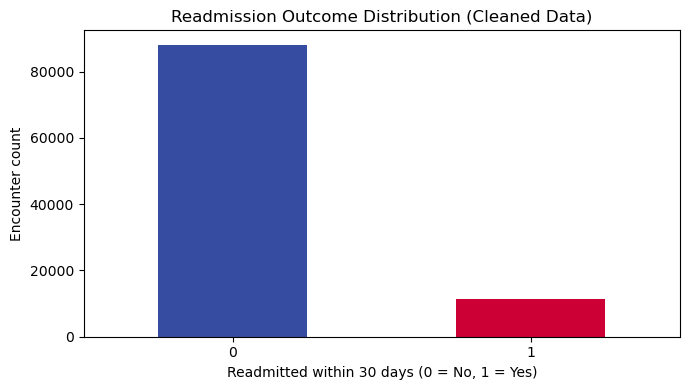

In [41]:
print("Readmission target distribution:")
readmission_counts = df["readmitted_30"].value_counts().reindex([0, 1])
display(pd.DataFrame({
    "count": readmission_counts,
    "percent": (readmission_counts / len(df) * 100).round(1)
}))

if HAS_PLOTTING:
    ax = readmission_counts.plot(kind="bar", figsize=(7, 4), color=[SMU_BLUE, SMU_RED])
    ax.set_title("Readmission Outcome Distribution (Cleaned Data)")
    ax.set_xlabel("Readmitted within 30 days (0 = No, 1 = Yes)")
    ax.set_ylabel("Encounter count")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Plot skipped because matplotlib is not installed.")


## 5. EDA for the Business Problem

I use EDA to check whether the data supports a care-management triage decision.

The most useful charts show:

- class imbalance
- missingness before cleaning
- readmission patterns by age, utilization, medication burden, A1C, and discharge setting
- why ranking and capacity metrics are more useful than accuracy


,label,count,percent
0,Not readmitted within 30 days,88026,88.6
1,Readmitted within 30 days,11314,11.4


,encounters,avg_time_in_hospital,avg_prior_inpatient,avg_prior_emergency,avg_prior_outpatient,avg_total_prior_visits,avg_num_medications,avg_active_diabetes_meds
readmitted_30,,,,,,,,
0,88026,4.33,0.55,0.18,0.36,1.09,15.86,1.18
1,11314,4.77,1.22,0.36,0.44,2.02,16.91,1.19


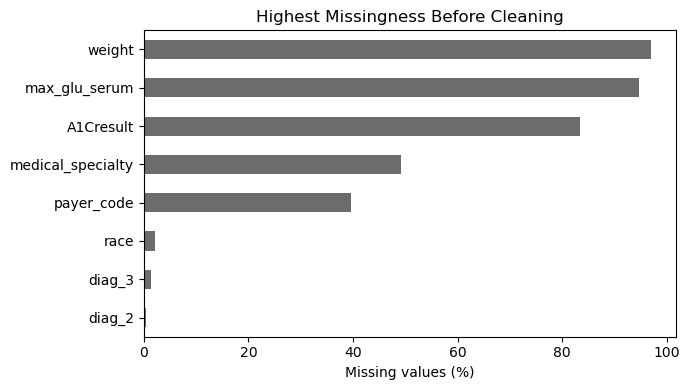

Readmission rate by age bracket:


,encounters,readmission_rate,population_share
age,,,
[20-30),1649,14.3,1.7
[80-90),16434,12.6,16.5
[70-80),25329,12.1,25.5
[90-100),2589,11.9,2.6
[30-40),3764,11.3,3.8
[60-70),22058,11.3,22.2
[40-50),9607,10.7,9.7
[50-60),17060,9.8,17.2
[10-20),690,5.8,0.7


Readmission rate by prior utilization group:


,encounters,readmission_rate,population_share
total_prior_visits_group,,,
5+,6315,23.7,6.4
3-4,9145,16.5,9.2
2,9753,15.0,9.8
1,19454,11.8,19.6
0,54673,8.3,55.0


Readmission rate by discharge destination group:


,encounters,readmission_rate,population_share
discharge_group,,,
Rehab facility,1992,27.7,2.0
Other inpatient facility,1184,20.9,1.2
Short-term hospital transfer,2128,16.1,2.1
Skilled nursing facility,13954,14.7,14.0
Intermediate care facility,815,12.8,0.8
Home health,12902,12.7,13.0
Other/unknown,4707,11.9,4.7
Home,60232,9.3,60.6


Readmission rate by A1C result:


,encounters,readmission_rate,population_share
A1Cresult,,,
Unknown,82506,11.7,83.1
>7,3775,10.1,3.8
>8,8137,9.9,8.2
Norm,4922,9.8,5.0


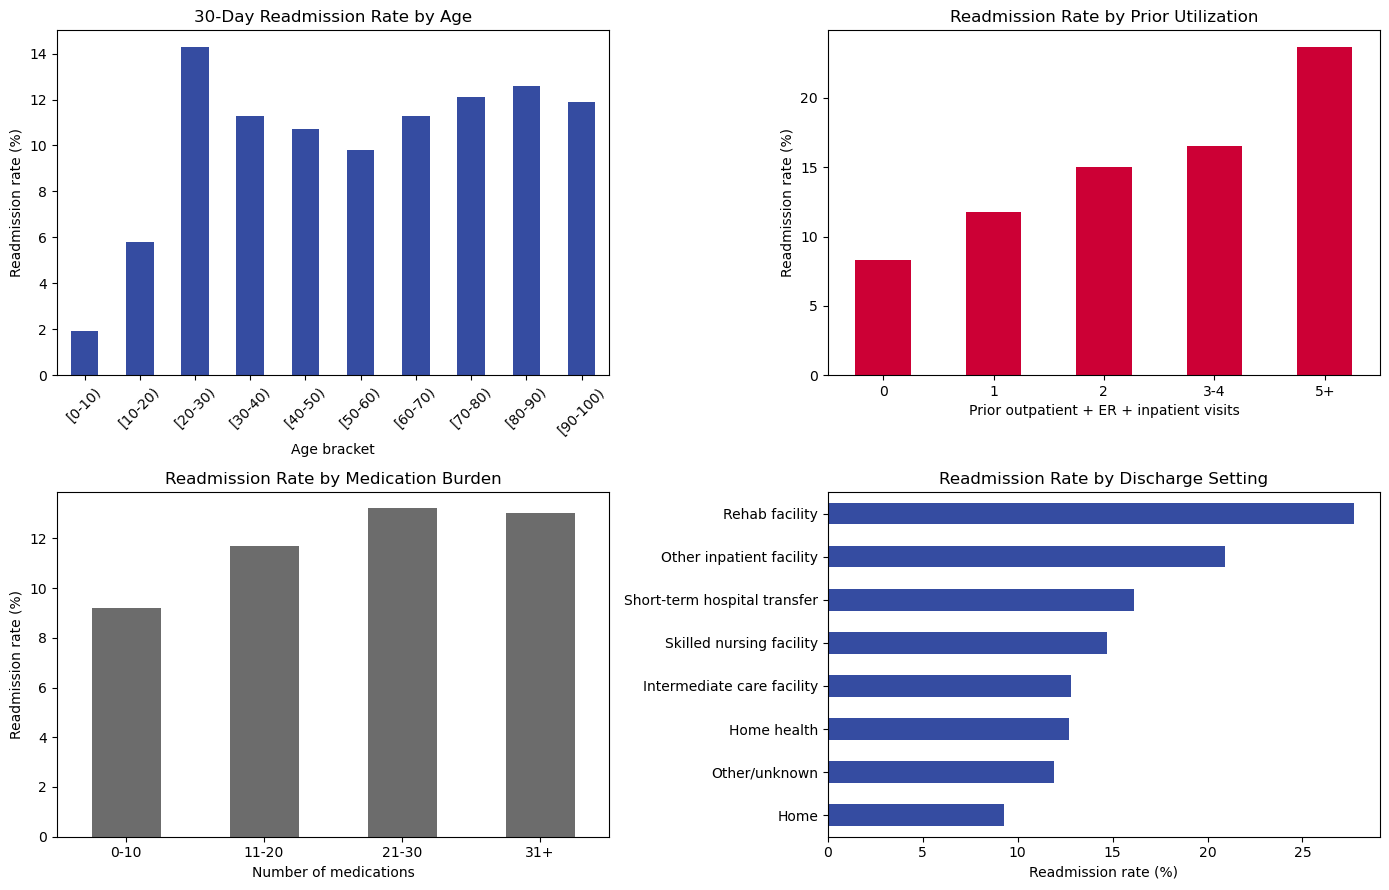

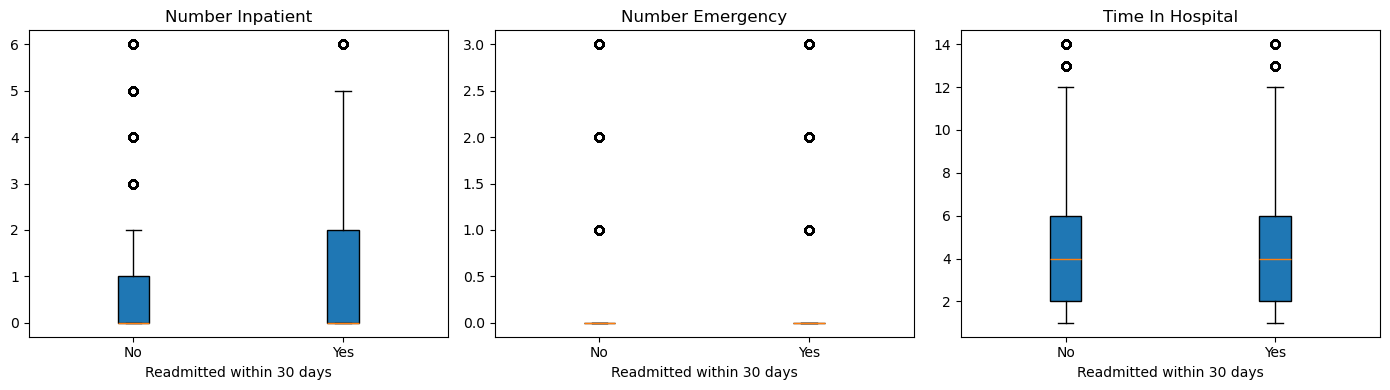

In [42]:
target_summary = df["readmitted_30"].value_counts().sort_index()
display(pd.DataFrame({
    "label": ["Not readmitted within 30 days", "Readmitted within 30 days"],
    "count": target_summary.values,
    "percent": (target_summary.values / len(df) * 100).round(1),
}))

eda_summary = df.groupby("readmitted_30").agg(
    encounters=("readmitted_30", "size"),
    avg_time_in_hospital=("time_in_hospital", "mean"),
    avg_prior_inpatient=("number_inpatient", "mean"),
    avg_prior_emergency=("number_emergency", "mean"),
    avg_prior_outpatient=("number_outpatient", "mean"),
    avg_total_prior_visits=("total_prior_visits", "mean"),
    avg_num_medications=("num_medications", "mean"),
    avg_active_diabetes_meds=("num_active_diabetes_meds", "mean"),
).round(2)
display(eda_summary)

missing_plot = cleaning_report["top_missing_before_cleaning"].copy().mul(100).round(1)
missing_plot = missing_plot[missing_plot > 0].sort_values(ascending=True)

if HAS_PLOTTING and len(missing_plot):
    ax = missing_plot.plot(kind="barh", figsize=(7, 4), color=SMU_GRAY)
    ax.set_title("Highest Missingness Before Cleaning")
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Missingness plot skipped because matplotlib is not installed or no missing values were found.")

eda_plot_df = df.copy()
eda_plot_df["prior_inpatient_group"] = pd.cut(
    eda_plot_df["number_inpatient"],
    bins=[-0.1, 0, 1, 2, 4, np.inf],
    labels=["0", "1", "2", "3-4", "5+"],
)
eda_plot_df["total_prior_visits_group"] = pd.cut(
    eda_plot_df["total_prior_visits"],
    bins=[-0.1, 0, 1, 2, 4, np.inf],
    labels=["0", "1", "2", "3-4", "5+"],
)
eda_plot_df["med_burden_group"] = pd.cut(
    eda_plot_df["num_medications"],
    bins=[-0.1, 10, 20, 30, np.inf],
    labels=["0-10", "11-20", "21-30", "31+"],
)


def readmission_rate_table(data, column, min_count=250, top_n=None):
    table = data.groupby(column, observed=False).agg(
        encounters=("readmitted_30", "size"),
        readmission_rate=("readmitted_30", "mean"),
    )
    table = table[table["encounters"] >= min_count].copy()
    table["readmission_rate"] = (table["readmission_rate"] * 100).round(1)
    table["population_share"] = (table["encounters"] / len(data) * 100).round(1)
    if top_n:
        table = table.sort_values("encounters", ascending=False).head(top_n)
    return table.sort_values("readmission_rate", ascending=False)

age_rate = readmission_rate_table(eda_plot_df, "age", min_count=100)
prior_rate = readmission_rate_table(eda_plot_df, "total_prior_visits_group", min_count=100)
med_rate = readmission_rate_table(eda_plot_df, "med_burden_group", min_count=100)
discharge_rate = readmission_rate_table(eda_plot_df, "discharge_group", min_count=500, top_n=8)
admission_source_rate = readmission_rate_table(eda_plot_df, "admission_source_group", min_count=500)
a1c_rate = readmission_rate_table(eda_plot_df, "A1Cresult", min_count=500)

print("Readmission rate by age bracket:")
display(age_rate)
print("Readmission rate by prior utilization group:")
display(prior_rate)
print("Readmission rate by discharge destination group:")
display(discharge_rate)
print("Readmission rate by A1C result:")
display(a1c_rate)

if HAS_PLOTTING:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    age_rate.sort_index()["readmission_rate"].plot(kind="bar", ax=axes[0, 0], color=SMU_BLUE)
    axes[0, 0].set_title("30-Day Readmission Rate by Age")
    axes[0, 0].set_xlabel("Age bracket")
    axes[0, 0].set_ylabel("Readmission rate (%)")
    axes[0, 0].tick_params(axis="x", rotation=45)

    prior_rate.sort_index()["readmission_rate"].plot(kind="bar", ax=axes[0, 1], color=SMU_RED)
    axes[0, 1].set_title("Readmission Rate by Prior Utilization")
    axes[0, 1].set_xlabel("Prior outpatient + ER + inpatient visits")
    axes[0, 1].set_ylabel("Readmission rate (%)")
    axes[0, 1].tick_params(axis="x", rotation=0)

    med_rate.sort_index()["readmission_rate"].plot(kind="bar", ax=axes[1, 0], color=SMU_GRAY)
    axes[1, 0].set_title("Readmission Rate by Medication Burden")
    axes[1, 0].set_xlabel("Number of medications")
    axes[1, 0].set_ylabel("Readmission rate (%)")
    axes[1, 0].tick_params(axis="x", rotation=0)

    discharge_rate.sort_values("readmission_rate")["readmission_rate"].plot(kind="barh", ax=axes[1, 1], color=SMU_BLUE)
    axes[1, 1].set_title("Readmission Rate by Discharge Setting")
    axes[1, 1].set_xlabel("Readmission rate (%)")
    axes[1, 1].set_ylabel("")

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    numeric_features_to_compare = ["number_inpatient", "number_emergency", "time_in_hospital"]
    for ax, feature in zip(axes, numeric_features_to_compare):
        data_to_plot = [
            df.loc[df["readmitted_30"] == 0, feature].clip(upper=df[feature].quantile(0.99)),
            df.loc[df["readmitted_30"] == 1, feature].clip(upper=df[feature].quantile(0.99)),
        ]
        ax.boxplot(data_to_plot, tick_labels=["No", "Yes"], patch_artist=True)
        ax.set_title(feature.replace("_", " ").title())
        ax.set_xlabel("Readmitted within 30 days")
    plt.tight_layout()
    plt.show()
else:
    print("EDA plots skipped because matplotlib is not installed.")


### EDA Takeaways

- The 30-day readmission class is imbalanced, so accuracy is not enough.
- Prior utilization, discharge setting, medication burden, and age are useful triage signals.
- The stakeholder needs a ranked worklist and scenario planner, not just a yes/no prediction.
- These are predictive patterns, not causal claims.


## 6. Decision Metrics, KPI, and Assumptions

This is an imbalanced classification problem, but the business decision is capacity-based.

**Primary KPI:** `recall at capacity`

\[
	ext{Recall at capacity} = 
rac{	ext{Actual 30-day readmissions captured in the top N patients}}{	ext{All actual 30-day readmissions}}
\]

Supporting metrics:

- **Precision at capacity:** share of selected patients who were readmitted.
- **Lift:** how much better the worklist is than random selection.
- **PR-AUC:** ranking quality for the rare positive class.
- **Brier score / calibration:** whether probabilities are reliable enough for cost math.
- **Accuracy / F1 / ROC-AUC:** useful diagnostics, but not the main decision metrics.

Default scenario assumptions:

| Assumption | Default |
|---|---:|
| Intervention capacity | 500 patients |
| Cost per readmission | $15,000 |
| Cost per intervention | $300 |
| Intervention effectiveness | 10% |

Expected net value:

\[
(\sum 	ext{selected calibrated risk} 	imes 	ext{effectiveness} 	imes 	ext{readmission cost}) - (	ext{patients targeted} 	imes 	ext{intervention cost})
\]

These assumptions are adjustable scenario inputs, not measured financial outcomes.


In [43]:

decision_canvas = pd.DataFrame({
    "Project element": [
        "Stakeholder",
        "Decision",
        "Action options",
        "Primary operating KPI",
        "Hyperparameter tuning objective",
        "Executive KPI",
        "Model output",
        "Business constraint",
        "Default business equation",
        "RAG role",
        "Fine-tuned model role",
    ],
    "Working definition": [
        "Director of Care Management / Transitional Care Manager",
        "Which eligible diabetes discharges should receive enhanced post-discharge support?",
        "Routine discharge, follow-up call + appointment coordination, or intensive nurse/pharmacist review",
        f"Recall at capacity: capture as many true 30-day readmissions as possible in the top {DEFAULT_CAPACITY} intervention slots",
        "Use a small patient-grouped cross-validation search scored by PR-AUC, because the target is imbalanced and the model is used for risk ranking",
        "Estimated net value from avoided readmissions minus intervention cost",
        "Calibrated probability of readmission within 30 days plus risk tier and ranked worklist",
        "Limited staff capacity and intervention budget",
        "Net value = sum(selected risk) * effectiveness * readmission cost - selected patients * intervention cost",
        "Retrieve CMS/AHRQ guidance to connect risk patterns to evidence-informed discharge actions",
        "Compare a required fine-tuned readmission classifier against the tabular ML pipeline using the same capacity and cost metrics",
    ],
})

display(decision_canvas)


,Project element,Working definition
0,Stakeholder,Director of Care Management / Transitional Car...
1,Decision,Which eligible diabetes discharges should rece...
2,Action options,"Routine discharge, follow-up call + appointmen..."
3,Primary operating KPI,Recall at capacity: capture as many true 30-da...
4,Hyperparameter tuning objective,Use a small patient-grouped cross-validation s...
5,Executive KPI,Estimated net value from avoided readmissions ...
6,Model output,Calibrated probability of readmission within 3...
7,Business constraint,Limited staff capacity and intervention budget
8,Default business equation,Net value = sum(selected risk) * effectiveness...
9,RAG role,Retrieve CMS/AHRQ guidance to connect risk pat...


## 7. Modeling Pipeline

Modeling workflow:

1. Split by patient to avoid leakage.
2. Use one shared preprocessing pipeline.
3. Train each candidate model separately.
4. Compare models with one clean metrics table.
5. Tune only the selected model family.

The best model is the one that creates the most useful high-risk worklist under limited capacity.


### 7a. Target, Features, and Patient-Level Split

In [44]:
y = df["readmitted_30"]
groups = df["patient_nbr"]

identifier_columns = ["encounter_id", "patient_nbr"]
redundant_columns = [
    "age",
    "admission_type_description",
    "discharge_disposition_description",
    "admission_source_description",
]
feature_drop_columns = ["readmitted", "readmitted_30"] + identifier_columns + redundant_columns

X = df.drop(columns=[col for col in feature_drop_columns if col in df.columns])

# Patient-level split prevents leakage from repeat encounters for the same patient.
group_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(group_split.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "encounters": [len(X_train), len(X_test)],
    "unique_patients": [train_groups.nunique(), test_groups.nunique()],
    "readmission_30_rate": [y_train.mean(), y_test.mean()],
})

overlap = set(train_groups).intersection(set(test_groups))
print("Patient overlap between train and test:", len(overlap))
display(split_summary.round(4))

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Excluded identifier columns:", identifier_columns)


Patient overlap between train and test: 0


,split,encounters,unique_patients,readmission_30_rate
0,train,79567,55989,0.1140
1,test,19773,13998,0.1135


Numeric features: 29
Categorical features: 10
Excluded identifier columns: ['encounter_id', 'patient_nbr']


### 7b. Shared Preprocessing

In [45]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_encoder(sparse=True)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

# HistGradientBoosting needs dense input, so it gets the same preprocessing logic with dense one-hot output.
categorical_pipe_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_encoder(sparse=False)),
])

preprocessor_dense = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe_dense, categorical_features),
])


### 7c. Baseline Logistic Regression

In [46]:
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])


### 7d. Balanced Logistic Regression

In [47]:
balanced_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])


### 7e. Balanced Random Forest

In [48]:
random_forest_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])


### 7f. Gradient Boosting

In [49]:
gradient_boosting_model = Pipeline(steps=[
    ("preprocess", preprocessor_dense),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    )),
])


### 7g. Model Metrics Comparison

Accuracy is shown for context. I select the model using capacity metrics: precision, recall, lift, and expected net value for the top `DEFAULT_CAPACITY` patients.


In [50]:
def capacity_metrics(y_true, y_score, capacity):
    """Evaluate the top-N highest-risk patients as the care-management worklist."""
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_score = pd.Series(y_score).reset_index(drop=True)
    capacity = min(int(capacity), len(y_true))

    selected_idx = y_score.sort_values(ascending=False).head(capacity).index
    selected_actual = y_true.iloc[selected_idx]
    actual_total = y_true.sum()
    base_rate = y_true.mean()

    precision_at_capacity = selected_actual.mean() if capacity > 0 else 0
    recall_at_capacity = selected_actual.sum() / actual_total if actual_total else 0
    lift = precision_at_capacity / base_rate if base_rate else np.nan

    return {
        f"precision_at_{capacity}": precision_at_capacity,
        f"recall_at_{capacity}": recall_at_capacity,
        f"lift_at_{capacity}": lift,
        f"readmissions_captured_at_{capacity}": int(selected_actual.sum()),
    }


def expected_net_value_at_capacity(y_score, capacity, readmission_cost, intervention_cost, effectiveness):
    scores = pd.Series(y_score).sort_values(ascending=False).head(int(capacity))
    return scores.sum() * effectiveness * readmission_cost - len(scores) * intervention_cost


def evaluate_model(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    cap = capacity_metrics(y_test, proba, DEFAULT_CAPACITY)

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_at_0_50": precision_score(y_test, pred, zero_division=0),
        "recall_at_0_50": recall_score(y_test, pred, zero_division=0),
        "f1_at_0_50": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "avg_precision_pr_auc": average_precision_score(y_test, proba),
        "brier_score": brier_score_loss(y_test, proba),
        "expected_net_value_at_capacity": expected_net_value_at_capacity(
            proba,
            DEFAULT_CAPACITY,
            DEFAULT_READMISSION_COST,
            DEFAULT_INTERVENTION_COST,
            DEFAULT_EFFECTIVENESS,
        ),
    }
    row.update(cap)
    return row, pred, proba


models = {
    "Baseline Logistic Regression": baseline_model,
    "Balanced Logistic Regression": balanced_model,
    "Balanced Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model,
}

model_scores = {}
rows = []
for name, model in models.items():
    row, pred, proba = evaluate_model(name, model)
    rows.append(row)
    model_scores[name] = {"pred": pred, "proba": proba}

capacity_key = DEFAULT_CAPACITY
results_raw = pd.DataFrame(rows).set_index("model")
selection_order = results_raw.sort_values(
    [f"recall_at_{capacity_key}", "avg_precision_pr_auc", "brier_score"],
    ascending=[False, False, True],
)
results = selection_order.round(4)

comparison_display = selection_order.rename(columns={
    "accuracy": "Accuracy",
    "roc_auc": "ROC-AUC",
    "avg_precision_pr_auc": "PR-AUC",
    "brier_score": "Brier",
    f"precision_at_{capacity_key}": f"Precision@{capacity_key}",
    f"recall_at_{capacity_key}": f"Recall@{capacity_key}",
    f"lift_at_{capacity_key}": f"Lift@{capacity_key}",
    f"readmissions_captured_at_{capacity_key}": f"Readmissions Captured@{capacity_key}",
    "expected_net_value_at_capacity": f"Estimated Net Value@{capacity_key}",
})[[
    "Accuracy",
    "ROC-AUC",
    "PR-AUC",
    "Brier",
    f"Precision@{capacity_key}",
    f"Recall@{capacity_key}",
    f"Lift@{capacity_key}",
    f"Readmissions Captured@{capacity_key}",
    f"Estimated Net Value@{capacity_key}",
]]

display(comparison_display.round(4))

final_model_name = selection_order.index[0]
final_model = models[final_model_name]
y_pred = model_scores[final_model_name]["pred"]
y_proba = model_scores[final_model_name]["proba"]

print(f"Selected model family: {final_model_name}")
print(f"Selection rule: highest recall at top {DEFAULT_CAPACITY}, then PR-AUC, then lower Brier score.")


,Accuracy,ROC-AUC,PR-AUC,Brier,Precision@500,Recall@500,Lift@500,Readmissions Captured@500,Estimated Net Value@500
model,,,,,,,,,
Gradient Boosting,0.8871,0.6756,0.2423,0.0951,0.412,0.0918,3.6303,206,131832.5394
Baseline Logistic Regression,0.8876,0.6686,0.2239,0.0960,0.378,0.0842,3.3307,189,145877.4391
Balanced Random Forest,0.6875,0.6706,0.2214,0.2086,0.376,0.0838,3.3131,188,371776.9211
Balanced Logistic Regression,0.6632,0.6688,0.2233,0.2250,0.374,0.0833,3.2955,187,478769.2340


Selected model family: Gradient Boosting
Selection rule: highest recall at top 500, then PR-AUC, then lower Brier score.


### 7h. Simple Tuning

I keep tuning small and explainable: only the selected model family is tuned, using patient-grouped cross-validation and PR-AUC.


In [51]:
TUNING_SCORE = "average_precision"

tuning_param_grids = {
    "Baseline Logistic Regression": {
        "model__C": [0.01, 0.1, 1.0, 10.0],
    },
    "Balanced Logistic Regression": {
        "model__C": [0.01, 0.1, 1.0, 10.0],
    },
    "Balanced Random Forest": {
        "model__n_estimators": [120, 200],
        "model__max_depth": [8, 12, None],
        "model__min_samples_leaf": [25, 50, 100],
    },
    "Gradient Boosting": {
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__l2_regularization": [0.0, 1.0, 3.0],
    },
}

param_grid = tuning_param_grids[final_model_name]
grid_size = 1
for values in param_grid.values():
    grid_size *= len(values)

search = RandomizedSearchCV(
    estimator=final_model,
    param_distributions=param_grid,
    n_iter=min(6, grid_size),
    scoring=TUNING_SCORE,
    cv=GroupKFold(n_splits=3),
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
)
search.fit(X_train, y_train, groups=train_groups)

tuned_model = search.best_estimator_
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]

pre_tuning_capacity = capacity_metrics(y_test, y_proba, DEFAULT_CAPACITY)
tuned_capacity = capacity_metrics(y_test, tuned_proba, DEFAULT_CAPACITY)

tuning_results = pd.DataFrame({
    "Stage": ["Selected model", "Tuned selected model"],
    f"Precision@{DEFAULT_CAPACITY}": [
        pre_tuning_capacity[f"precision_at_{DEFAULT_CAPACITY}"],
        tuned_capacity[f"precision_at_{DEFAULT_CAPACITY}"],
    ],
    f"Recall@{DEFAULT_CAPACITY}": [
        pre_tuning_capacity[f"recall_at_{DEFAULT_CAPACITY}"],
        tuned_capacity[f"recall_at_{DEFAULT_CAPACITY}"],
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba),
        average_precision_score(y_test, tuned_proba),
    ],
    "Brier": [
        brier_score_loss(y_test, y_proba),
        brier_score_loss(y_test, tuned_proba),
    ],
})

display(tuning_results.round(4))
print(f"Tuned model family: {final_model_name}")
print("Best parameters:", search.best_params_)
print(f"Best grouped-CV PR-AUC: {search.best_score_:.4f}")

# Use the tuned model for calibration, scoring, explainability, and saved artifacts.
final_model = tuned_model
y_proba = tuned_proba
risk_for_operating_rule = pd.Series(y_proba, index=X_test.index)
selected_index = risk_for_operating_rule.sort_values(ascending=False).head(DEFAULT_CAPACITY).index
y_pred_capacity = pd.Series(0, index=X_test.index)
y_pred_capacity.loc[selected_index] = 1
y_pred = y_pred_capacity.loc[X_test.index].astype(int).values


,Stage,Precision@500,Recall@500,PR-AUC,Brier
0,Selected model,0.412,0.0918,0.2423,0.0951
1,Tuned selected model,0.406,0.0905,0.2400,0.0953


Tuned model family: Gradient Boosting
Best parameters: {'model__max_leaf_nodes': 15, 'model__learning_rate': 0.03, 'model__l2_regularization': 1.0}
Best grouped-CV PR-AUC: 0.2233


### 7i. Probability Calibration

The cost model uses the **sum of selected predicted risks** as expected readmissions. I calibrate the selected model before using probabilities in dollar estimates.

Below, the positive class means **selected into the top-N worklist**, not simply `probability >= 0.50`.


In [52]:

calibrated_model = CalibratedClassifierCV(final_model, method="isotonic", cv=3)
calibrated_model.fit(X_train, y_train)

brier_before = brier_score_loss(y_test, y_proba)
y_proba = calibrated_model.predict_proba(X_test)[:, 1]   # calibrated risk used downstream
brier_after = brier_score_loss(y_test, y_proba)

risk_for_operating_rule = pd.Series(y_proba, index=X_test.index)
selected_index = risk_for_operating_rule.sort_values(ascending=False).head(DEFAULT_CAPACITY).index
y_pred_capacity = pd.Series(0, index=X_test.index)
y_pred_capacity.loc[selected_index] = 1
y_pred = y_pred_capacity.loc[X_test.index].astype(int).values

calibrated_capacity_metrics = capacity_metrics(y_test, y_proba, DEFAULT_CAPACITY)
calibrated_net_value = expected_net_value_at_capacity(
    y_proba,
    DEFAULT_CAPACITY,
    DEFAULT_READMISSION_COST,
    DEFAULT_INTERVENTION_COST,
    DEFAULT_EFFECTIVENESS,
)

print(f"Calibrated the selected model ({final_model_name}).")
print(f"Brier score before: {brier_before:.4f} -> after: {brier_after:.4f} (lower is better).")
print(f"Operating rule: select the top {DEFAULT_CAPACITY} patients by calibrated risk.")
print(f"Calibrated precision at {DEFAULT_CAPACITY}: {calibrated_capacity_metrics[f'precision_at_{DEFAULT_CAPACITY}']:.3f}")
print(f"Calibrated recall at {DEFAULT_CAPACITY}: {calibrated_capacity_metrics[f'recall_at_{DEFAULT_CAPACITY}']:.3f}")
print(f"Calibrated expected net value at capacity: ${calibrated_net_value:,.0f}")


Calibrated the selected model (Gradient Boosting).
Brier score before: 0.0953 -> after: 0.0953 (lower is better).
Operating rule: select the top 500 patients by calibrated risk.
Calibrated precision at 500: 0.408
Calibrated recall at 500: 0.091
Calibrated expected net value at capacity: $113,691


Classification report for the top-500 capacity worklist:
              precision    recall  f1-score   support

Not selected       0.89      0.98      0.94     17529
    Selected       0.41      0.09      0.15      2244

    accuracy                           0.88     19773
   macro avg       0.65      0.54      0.54     19773
weighted avg       0.84      0.88      0.85     19773



,Not selected,Selected
Actual not <30,17233,296
Actual <30,2040,204


,risk_decile,patients,avg_predicted_risk,observed_readmission_rate
0,0,1992,0.0399,0.0366
1,1,2013,0.0569,0.0581
2,2,1991,0.0702,0.0628
3,3,1918,0.0818,0.0819
4,4,2074,0.0938,0.0902
5,5,1955,0.1105,0.1023
6,6,1900,0.1235,0.1200
7,7,2009,0.1384,0.1254
8,8,1957,0.1582,0.1809
9,9,1964,0.2417,0.2805


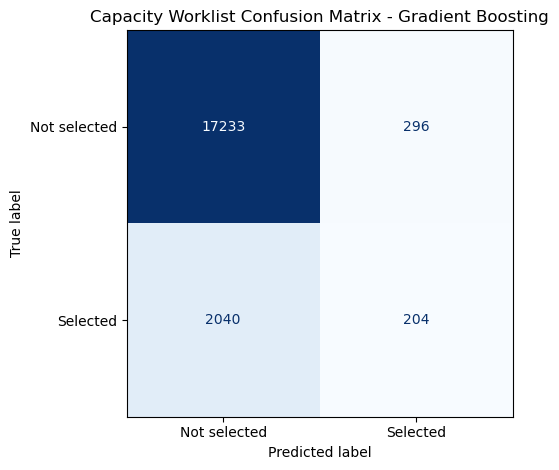

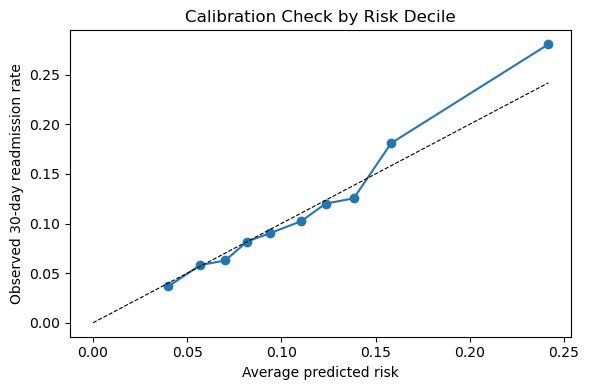

In [53]:

print(f"Classification report for the top-{DEFAULT_CAPACITY} capacity worklist:")
print(classification_report(y_test, y_pred, target_names=["Not selected", "Selected"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=["Actual not <30", "Actual <30"], columns=["Not selected", "Selected"] ))

calibration_table = pd.DataFrame({"actual": y_test.values, "risk_score": y_proba})
calibration_table["risk_decile"] = pd.qcut(
    calibration_table["risk_score"], q=10, labels=False, duplicates="drop"
)
calibration_summary = calibration_table.groupby("risk_decile").agg(
    patients=("actual", "size"),
    avg_predicted_risk=("risk_score", "mean"),
    observed_readmission_rate=("actual", "mean"),
).reset_index()
display(calibration_summary.round(4))

if HAS_PLOTTING:
    ConfusionMatrixDisplay(cm, display_labels=["Not selected", "Selected"]).plot(cmap="Blues", colorbar=False)
    plt.title(f"Capacity Worklist Confusion Matrix - {final_model_name}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(calibration_summary["avg_predicted_risk"], calibration_summary["observed_readmission_rate"], marker="o")
    max_risk = calibration_summary["avg_predicted_risk"].max()
    plt.plot([0, max_risk], [0, max_risk], linestyle="--", color="black", linewidth=0.8)
    plt.title("Calibration Check by Risk Decile")
    plt.xlabel("Average predicted risk")
    plt.ylabel("Observed 30-day readmission rate")
    plt.tight_layout()
    plt.show()
else:
    print("Plots skipped because matplotlib is not installed.")


## 8. Threshold and Capacity Analysis

A care-management team will not act on every score. This section turns model probabilities into operational choices: threshold cutoffs, number of patients flagged, expected readmissions captured, and workload size.


Threshold view


,threshold,patients_flagged,flagged_percent,precision,recall,f1,actual_readmissions_captured,actual_readmissions_total
0,0.05,17715,0.8959,0.1223,0.9652,0.2170,2166,2244
1,0.10,9950,0.5032,0.1606,0.7121,0.2621,1598,2244
2,0.15,3618,0.1830,0.2383,0.3841,0.2941,862,2244
3,0.20,1170,0.0592,0.3222,0.1680,0.2209,377,2244
4,0.25,619,0.0313,0.3845,0.1061,0.1663,238,2244
5,0.30,362,0.0183,0.4696,0.0758,0.1305,170,2244
6,0.35,222,0.0112,0.5495,0.0544,0.0989,122,2244
7,0.40,103,0.0052,0.6408,0.0294,0.0562,66,2244
8,0.45,40,0.0020,0.6500,0.0116,0.0228,26,2244
9,0.50,12,0.0006,0.5000,0.0027,0.0053,6,2244


Capacity view


,capacity,patients_selected,precision_at_capacity,recall_at_capacity,lift_over_random,actual_readmissions_captured
0,100,100,0.650,0.0290,5.7275,65
1,250,250,0.524,0.0584,4.6172,131
2,500,500,0.408,0.0909,3.5951,204
3,1000,1000,0.331,0.1475,2.9166,331
4,2000,2000,0.280,0.2496,2.4672,560


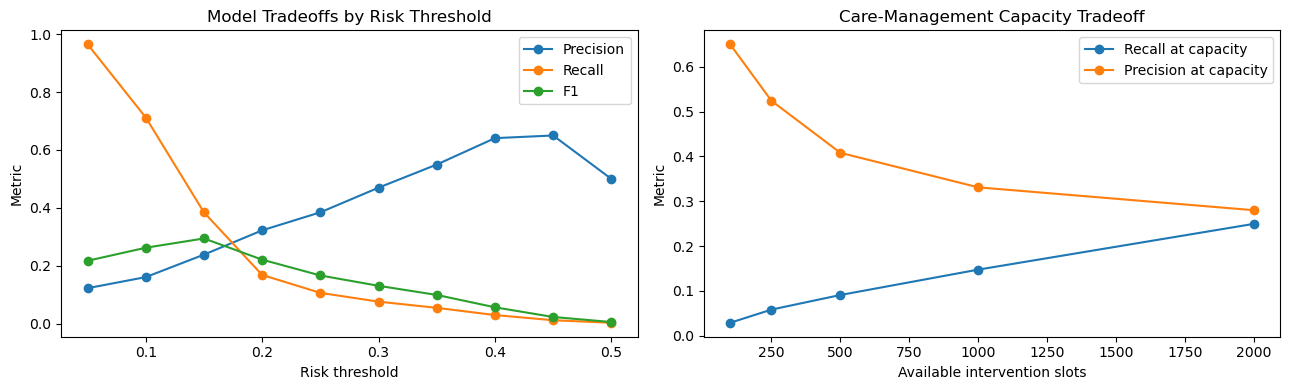

In [54]:
def evaluate_thresholds(y_true, y_score, thresholds=None):
    """Sweep a fixed probability threshold and report the resulting worklist size,
    precision, recall, and F1 at each cut point.

    This view answers a different operational question than ``capacity_metrics``: instead
    of fixing the number of intervention slots, it fixes the risk cutoff and lets the
    number of flagged patients float. Useful for showing the precision/recall trade-off
    curve to a stakeholder who thinks in terms of "risk score above X", not "top N patients".
    """
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 0.55, 0.05), 2)

    rows = []
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    total_actual = y_true.sum()

    for threshold in thresholds:
        pred = (y_score >= threshold).astype(int)
        flagged = pred.sum()
        rows.append({
            "threshold": threshold,
            "patients_flagged": int(flagged),
            "flagged_percent": flagged / len(y_true),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "actual_readmissions_captured": int(((pred == 1) & (y_true == 1)).sum()),
            "actual_readmissions_total": int(total_actual),
        })
    return pd.DataFrame(rows)


def evaluate_capacity_table(y_true, y_score, capacities=(100, 250, 500, 1000, 2000)):
    """Report precision/recall/lift at several staffing-capacity levels, using
    ``capacity_metrics`` from Section 7. This is the "how does the worklist perform if we
    can afford N intervention slots" view a care-management leader would actually plan
    around, as opposed to the threshold-based view above.
    """
    rows = []
    for capacity in capacities:
        metrics = capacity_metrics(y_true, y_score, capacity)
        actual_capacity = min(int(capacity), len(y_true))
        rows.append({
            "capacity": actual_capacity,
            "patients_selected": actual_capacity,
            "precision_at_capacity": metrics[f"precision_at_{actual_capacity}"],
            "recall_at_capacity": metrics[f"recall_at_{actual_capacity}"],
            "lift_over_random": metrics[f"lift_at_{actual_capacity}"],
            "actual_readmissions_captured": metrics[f"readmissions_captured_at_{actual_capacity}"],
        })
    return pd.DataFrame(rows)


threshold_table = evaluate_thresholds(y_test, y_proba)
capacity_table = evaluate_capacity_table(y_test, y_proba)

print("Threshold view")
display(threshold_table.round(4))
print("Capacity view")
display(capacity_table.round(4))

if HAS_PLOTTING:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(threshold_table["threshold"], threshold_table["precision"], marker="o", label="Precision")
    axes[0].plot(threshold_table["threshold"], threshold_table["recall"], marker="o", label="Recall")
    axes[0].plot(threshold_table["threshold"], threshold_table["f1"], marker="o", label="F1")
    axes[0].set_title("Model Tradeoffs by Risk Threshold")
    axes[0].set_xlabel("Risk threshold")
    axes[0].set_ylabel("Metric")
    axes[0].legend()

    axes[1].plot(capacity_table["capacity"], capacity_table["recall_at_capacity"], marker="o", label="Recall at capacity")
    axes[1].plot(capacity_table["capacity"], capacity_table["precision_at_capacity"], marker="o", label="Precision at capacity")
    axes[1].set_title("Care-Management Capacity Tradeoff")
    axes[1].set_xlabel("Available intervention slots")
    axes[1].set_ylabel("Metric")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Threshold/capacity plots skipped because matplotlib is not installed.")


## 9. Risk Scoring and Patient Prioritization

The model probability is converted into risk tiers and proposed support levels. This makes the output easier for care managers to use than a raw probability alone.


In [55]:
scored = df.loc[X_test.index, identifier_columns + [
    "age", "race", "gender", "time_in_hospital", "number_inpatient",
    "number_emergency", "number_outpatient", "discharge_group"
]].copy()
scored["actual_readmitted_30"] = y_test.values
scored["risk_score"] = y_proba
scored["risk_rank"] = scored["risk_score"].rank(method="first", ascending=False).astype(int)

scored["risk_tier"] = pd.qcut(
    scored["risk_score"],
    q=[0, 0.50, 0.80, 1.0],
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

support_level_map = {
    "Low": "Routine discharge support",
    "Medium": "Follow-up call + appointment coordination",
    "High": "Intensive nurse care management + medication review",
}
scored["recommended_support_level"] = scored["risk_tier"].astype(str).map(support_level_map)

tier_summary = scored.groupby("risk_tier", observed=True).agg(
    patients=("risk_score", "size"),
    avg_risk_score=("risk_score", "mean"),
    actual_readmission_rate=("actual_readmitted_30", "mean"),
    actual_readmissions=("actual_readmitted_30", "sum"),
).round(4)

display(tier_summary)
display(scored.sort_values("risk_score", ascending=False).head(10)[[
    "risk_rank", "encounter_id", "patient_nbr", "risk_score", "risk_tier", "recommended_support_level",
    "actual_readmitted_30", "age", "race", "gender", "time_in_hospital",
    "number_inpatient", "number_emergency", "number_outpatient", "discharge_group"
]])


,patients,avg_risk_score,actual_readmission_rate,actual_readmissions
risk_tier,,,,
Low,9988,0.0686,0.0660,659
Medium,5864,0.1243,0.1160,680
High,3921,0.2001,0.2308,905


,risk_rank,encounter_id,patient_nbr,risk_score,risk_tier,recommended_support_level,actual_readmitted_30,age,race,gender,time_in_hospital,number_inpatient,number_emergency,number_outpatient,discharge_group
29640,2,96617274,23643405,0.564348,High,Intensive nurse care management + medication r...,1,[20-30),Caucasian,Female,4,16,4,0,Home
30399,3,98317206,23643405,0.564348,High,Intensive nurse care management + medication r...,0,[20-30),Caucasian,Female,5,16,5,0,Home
28462,1,93304032,23643405,0.564348,High,Intensive nurse care management + medication r...,0,[20-30),Caucasian,Female,4,16,3,0,Home
69771,4,199082304,43787097,0.535021,High,Intensive nurse care management + medication r...,0,[80-90),Caucasian,Male,14,1,0,0,Short-term hospital transfer
68665,5,194138880,44024760,0.529645,High,Intensive nurse care management + medication r...,0,[80-90),Caucasian,Male,12,1,0,0,Short-term hospital transfer
23800,6,81201060,23643405,0.527957,High,Intensive nurse care management + medication r...,0,[20-30),Caucasian,Female,7,8,5,1,Other/unknown
27575,7,90320268,80385372,0.523934,High,Intensive nurse care management + medication r...,1,[70-80),Caucasian,Female,3,1,0,0,Short-term hospital transfer
26412,9,87099240,23643405,0.514008,High,Intensive nurse care management + medication r...,1,[20-30),Caucasian,Female,6,13,4,0,Home
88075,11,282472530,43140906,0.514008,High,Intensive nurse care management + medication r...,1,[20-30),Caucasian,Female,1,15,2,2,Home
24895,8,83859318,23643405,0.514008,High,Intensive nurse care management + medication r...,1,[20-30),Caucasian,Female,6,9,4,1,Home


## 10. Cost and Savings Scenario Analysis

This section connects the model to business value. The cost assumptions are adjustable because local intervention cost and effectiveness data are not available in the UCI dataset.


In [56]:
def estimate_intervention_value(
    scored_df,
    threshold=DEFAULT_THRESHOLD,
    capacity=None,
    readmission_cost=DEFAULT_READMISSION_COST,
    intervention_cost=DEFAULT_INTERVENTION_COST,
    intervention_effectiveness=DEFAULT_EFFECTIVENESS,
):
    """Full implementation of the Section 6 cost/value equation, for a chosen operating
    rule (a risk ``threshold``, an optional staffing ``capacity`` cap, or both together).

    This is the "scenario calculator" version of the equation implemented compactly in
    ``expected_net_value_at_capacity`` (Section 7) -- it is slower because it works from the
    full scored dataframe, but it also returns every intermediate quantity a stakeholder
    would want to see, not just the final net-value number.

    Equation term -> code:
        selected/eligible patients        -> `eligible` (risk >= threshold, then capped at capacity)
        patients targeted                 -> flagged_patients
        expected readmissions (no action) -> expected_readmissions = sum(selected risk)
        intervention effectiveness        -> intervention_effectiveness
        expected readmissions avoided     -> prevented_readmissions = expected_readmissions * effectiveness
        cost per readmission              -> readmission_cost
        gross avoided cost                -> gross_avoided_cost = prevented_readmissions * readmission_cost
        cost per intervention              -> intervention_cost
        total intervention cost           -> total_intervention_cost = flagged_patients * intervention_cost
        estimated net value               -> net_value = gross_avoided_cost - total_intervention_cost

    ``break_even_effectiveness`` answers a related question: holding the selected
    population fixed, how effective would the intervention need to be for its cost to
    exactly offset the avoided-readmission savings (net value = 0)?
    """
    eligible = scored_df[scored_df["risk_score"] >= threshold].sort_values("risk_score", ascending=False).copy()
    if capacity is not None:
        eligible = eligible.head(int(capacity))

    flagged_patients = len(eligible)
    expected_readmissions = eligible["risk_score"].sum()
    observed_readmissions = eligible["actual_readmitted_30"].sum() if "actual_readmitted_30" in eligible else np.nan
    prevented_readmissions = expected_readmissions * intervention_effectiveness
    gross_avoided_cost = prevented_readmissions * readmission_cost
    total_intervention_cost = flagged_patients * intervention_cost
    net_value = gross_avoided_cost - total_intervention_cost
    break_even_effectiveness = (
        total_intervention_cost / (expected_readmissions * readmission_cost)
        if expected_readmissions > 0 and readmission_cost > 0 else np.nan
    )

    return pd.Series({
        "threshold": threshold,
        "capacity": "No cap" if capacity is None else int(capacity),
        "patients_targeted": flagged_patients,
        "expected_readmissions_without_intervention": expected_readmissions,
        "observed_readmissions_in_selected_test_rows": observed_readmissions,
        "assumed_intervention_effectiveness": intervention_effectiveness,
        "expected_readmissions_avoided": prevented_readmissions,
        "gross_avoided_readmission_cost": gross_avoided_cost,
        "total_intervention_cost": total_intervention_cost,
        "estimated_net_value": net_value,
        "break_even_effectiveness": break_even_effectiveness,
    })


base_scenario = estimate_intervention_value(
    scored,
    threshold=DEFAULT_THRESHOLD,
    capacity=DEFAULT_CAPACITY,
    readmission_cost=DEFAULT_READMISSION_COST,
    intervention_cost=DEFAULT_INTERVENTION_COST,
    intervention_effectiveness=DEFAULT_EFFECTIVENESS,
)

display(base_scenario.to_frame("estimate"))


,estimate
threshold,0.000000
capacity,500.000000
patients_targeted,500.000000
expected_readmissions_without_intervention,175.794279
observed_readmissions_in_selected_test_rows,204.000000
assumed_intervention_effectiveness,0.100000
expected_readmissions_avoided,17.579428
gross_avoided_readmission_cost,263691.419246
total_intervention_cost,150000.000000
estimated_net_value,113691.419246


,threshold,capacity,patients_targeted,expected_readmissions_without_intervention,observed_readmissions_in_selected_test_rows,assumed_intervention_effectiveness,expected_readmissions_avoided,gross_avoided_readmission_cost,total_intervention_cost,estimated_net_value,break_even_effectiveness
3,0.20,No cap,1170.0,327.24,377.0,0.1,32.72,490856.21,351000.0,139856.21,0.07
2,0.20,1000.0,1000.0,292.47,332.0,0.1,29.25,438705.06,300000.0,138705.06,0.07
6,0.25,1000.0,619.0,206.41,238.0,0.1,20.64,309609.30,185700.0,123909.30,0.06
7,0.25,No cap,619.0,206.41,238.0,0.1,20.64,309609.30,185700.0,123909.30,0.06
5,0.25,500.0,500.0,175.79,204.0,0.1,17.58,263691.42,150000.0,113691.42,0.06
1,0.20,500.0,500.0,175.79,204.0,0.1,17.58,263691.42,150000.0,113691.42,0.06
10,0.30,1000.0,362.0,136.54,170.0,0.1,13.65,204805.73,108600.0,96205.73,0.05
9,0.30,500.0,362.0,136.54,170.0,0.1,13.65,204805.73,108600.0,96205.73,0.05
11,0.30,No cap,362.0,136.54,170.0,0.1,13.65,204805.73,108600.0,96205.73,0.05
0,0.20,250.0,250.0,100.62,131.0,0.1,10.06,150924.59,75000.0,75924.59,0.05


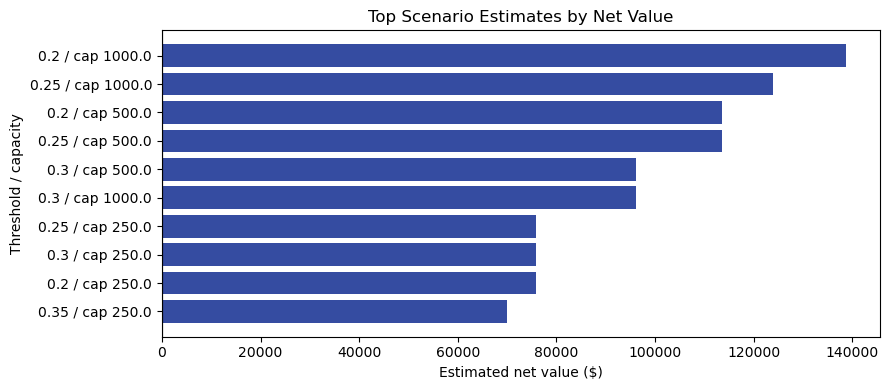

In [57]:
scenario_rows = []
for threshold in [0.20, 0.25, 0.30, 0.35, 0.40]:
    for capacity in [250, 500, 1000, None]:
        scenario_rows.append(estimate_intervention_value(
            scored,
            threshold=threshold,
            capacity=capacity,
            readmission_cost=DEFAULT_READMISSION_COST,
            intervention_cost=DEFAULT_INTERVENTION_COST,
            intervention_effectiveness=DEFAULT_EFFECTIVENESS,
        ))

scenario_table = pd.DataFrame(scenario_rows)
scenario_table = scenario_table.sort_values("estimated_net_value", ascending=False)
display(scenario_table.round(2))

if HAS_PLOTTING:
    plt.figure(figsize=(9, 4))
    plot_data = scenario_table[scenario_table["capacity"].astype(str) != "No cap"].copy().head(10)
    plot_data = plot_data.sort_values("estimated_net_value")
    plot_data["scenario"] = plot_data["threshold"].astype(str) + " / cap " + plot_data["capacity"].astype(str)
    plt.barh(plot_data["scenario"], plot_data["estimated_net_value"], color=SMU_BLUE)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Top Scenario Estimates by Net Value")
    plt.xlabel("Estimated net value ($)")
    plt.ylabel("Threshold / capacity")
    plt.tight_layout()
    plt.show()
else:
    print("Scenario plot skipped because matplotlib is not installed.")


### 10b. Marginal Value and Break-Even

Core question: **when does serving one more patient stop being worth it?**

Break-even risk:

\[
	ext{intervention cost} \div (	ext{effectiveness} 	imes 	ext{readmission cost})
\]

Patients above that risk have positive expected value under the default assumptions.


Break-even risk: serve while calibrated risk >= 0.200
Patients above break-even risk in the test set: 1170
Marginal net value turns negative near 1300 patients under these assumptions.


,capacity,cumulative_net_value,marginal_net_per_100
0,100,37915.0,NaN
2,300,85749.0,21015.0
4,500,113691.0,12009.0
9,1000,138705.0,1953.0
19,2000,121585.0,-3644.0
39,4000,-5864.0,-7868.0


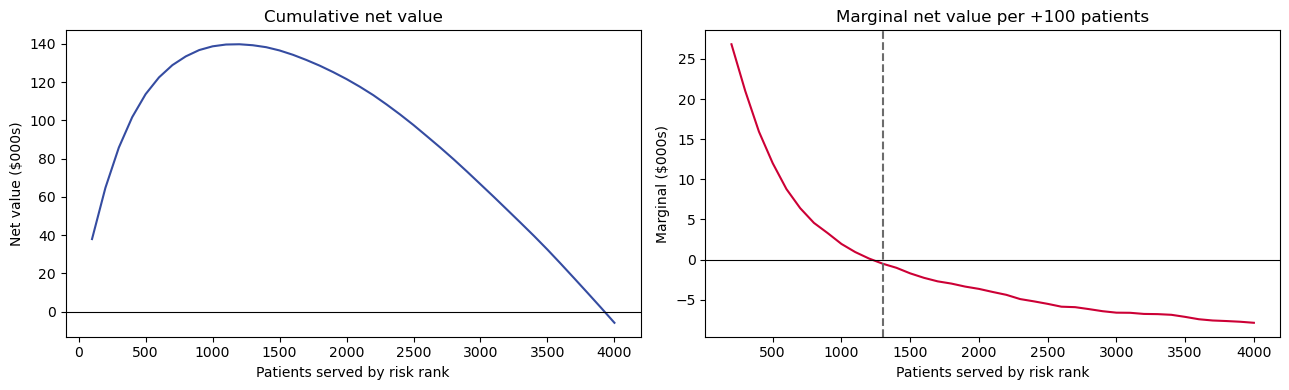

In [58]:

readmission_cost = DEFAULT_READMISSION_COST
intervention_cost = DEFAULT_INTERVENTION_COST
effectiveness = DEFAULT_EFFECTIVENESS

be_risk = intervention_cost / (effectiveness * readmission_cost)
n_worth = int((scored["risk_score"] >= be_risk).sum())
print(f"Break-even risk: serve while calibrated risk >= {be_risk:.3f}")
print(f"Patients above break-even risk in the test set: {n_worth}")

ranked = scored.sort_values("risk_score", ascending=False).reset_index(drop=True)
caps = list(range(100, 4001, 100))
marg = pd.DataFrame({"capacity": caps})
marg["cumulative_net_value"] = [
    ranked.head(c)["risk_score"].sum() * effectiveness * readmission_cost - c * intervention_cost
    for c in caps
]
marg["marginal_net_per_100"] = marg["cumulative_net_value"].diff()
opt = marg.loc[marg["marginal_net_per_100"] < 0, "capacity"].min()

if pd.isna(opt):
    print("Marginal net value stays positive across the tested capacity range under these assumptions.")
else:
    print(f"Marginal net value turns negative near {opt} patients under these assumptions.")

display(marg[marg["capacity"].isin([100, 300, 500, 1000, 2000, 4000])].round(0))

if HAS_PLOTTING:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(marg["capacity"], marg["cumulative_net_value"] / 1000, color=SMU_BLUE)
    ax[0].axhline(0, color="black", lw=0.8)
    ax[0].set_title("Cumulative net value")
    ax[0].set_xlabel("Patients served by risk rank")
    ax[0].set_ylabel("Net value ($000s)")
    ax[1].plot(marg["capacity"], marg["marginal_net_per_100"] / 1000, color=SMU_RED)
    ax[1].axhline(0, color="black", lw=0.8)
    if pd.notna(opt):
        ax[1].axvline(opt, ls="--", color=SMU_GRAY)
    ax[1].set_title("Marginal net value per +100 patients")
    ax[1].set_xlabel("Patients served by risk rank")
    ax[1].set_ylabel("Marginal ($000s)")
    plt.tight_layout()
    plt.show()


## 11. Explainability for Stakeholders

A business-facing product should explain why patients or segments are flagged, while avoiding overclaiming clinical causality from an observational dataset.


,feature,importance,std
26,discharge_group,0.05147,0.00642
9,number_inpatient,0.04972,0.00483
36,diag_1_chapter,0.01828,0.00166
37,diag_2_chapter,0.00638,0.00203
29,age_ordinal,0.00375,0.00114
27,admission_type_group,0.00242,0.00066
10,number_diagnoses,0.00225,0.00154
8,number_emergency,0.00219,0.00133
34,tests_per_day,0.00170,0.00216
13,metformin,0.00166,0.00078


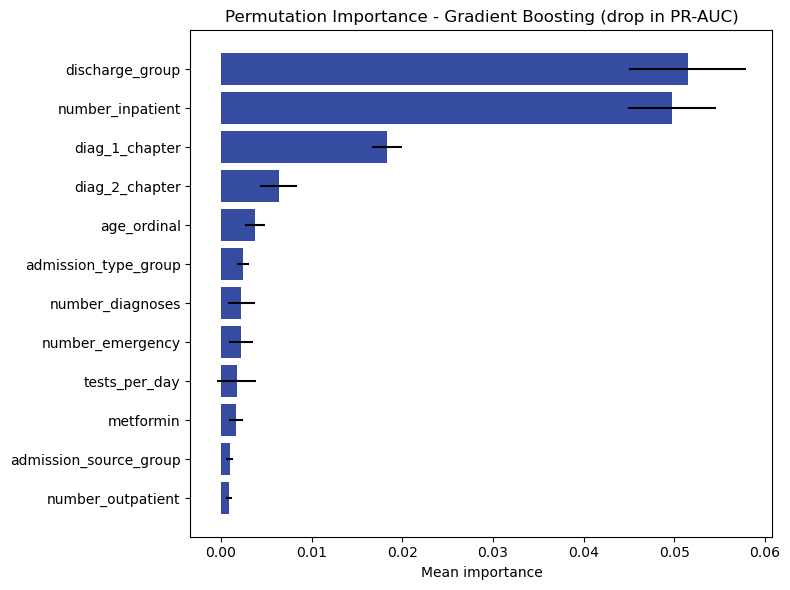

In [59]:
# Permutation importance works for ANY model, including gradient boosting (which has
# no coefficients). It measures how far PR-AUC drops when each feature is shuffled.
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_imp, y_imp = X_test.iloc[sample_idx], y_test.iloc[sample_idx]

perm = permutation_importance(final_model, X_imp, y_imp, scoring="average_precision",
                              n_repeats=5, random_state=RANDOM_STATE)
importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=False)
display(importance.head(15).round(5))

if HAS_PLOTTING:
    top = importance.head(12).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top["importance"], xerr=top["std"], color=SMU_BLUE)
    plt.title(f"Permutation Importance - {final_model_name} (drop in PR-AUC)")
    plt.xlabel("Mean importance"); plt.tight_layout(); plt.show()
else:
    print("Explanation plot skipped because matplotlib is not installed.")


### Stakeholder Interpretation

I translate model drivers into care-management language:

- prior inpatient visits may signal recent instability
- emergency visits may signal unresolved urgent needs
- discharge setting may show post-discharge complexity
- number of diagnoses may reflect comorbidity burden
- medication activity may show treatment changes

These are decision-support signals, not causal explanations.


## 12. Fairness, Limitations, and Appropriate Use

I check performance across demographic groups because a deployed decision-support tool should not hide uneven recall, false negatives, or calibration issues.


In [60]:
fairness_df = df.loc[X_test.index, ["race", "gender", "age"]].copy()
fairness_df["actual"] = y_test.values
fairness_df["predicted"] = y_pred
fairness_df["risk_score"] = y_proba

def group_metrics(data, group_col):
    rows = []
    for value, group in data.groupby(group_col, dropna=False):
        if len(group) < 50:
            continue
        group_pred = group["predicted"]
        group_actual = group["actual"]
        recall = recall_score(group_actual, group_pred, zero_division=0)
        rows.append({
            "group": value,
            "n": len(group),
            "actual_rate": group_actual.mean(),
            "avg_risk_score": group["risk_score"].mean(),
            "predicted_positive_rate": group_pred.mean(),
            "recall": recall,
            "false_negative_rate": 1 - recall,
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)

print("Fairness by race")
display(group_metrics(fairness_df, "race").round(4))

print("Fairness by gender")
display(group_metrics(fairness_df, "gender").round(4))

print("Fairness by age")
display(group_metrics(fairness_df, "age").round(4))


Fairness by race


,group,n,actual_rate,avg_risk_score,predicted_positive_rate,recall,false_negative_rate
2,Caucasian,14813,0.1172,0.1126,0.0265,0.0974,0.9026
0,AfricanAmerican,3697,0.1079,0.1099,0.0233,0.0652,0.9348
5,Unknown,447,0.0716,0.0958,0.0134,0.0312,0.9688
3,Hispanic,398,0.0905,0.1026,0.0251,0.1667,0.8333
4,Other,302,0.1026,0.0976,0.0199,0.0645,0.9355
1,Asian,116,0.0862,0.0937,0.0000,0.0000,1.0000


Fairness by gender


,group,n,actual_rate,avg_risk_score,predicted_positive_rate,recall,false_negative_rate
0,Female,10726,0.1145,0.1134,0.0250,0.0920,0.9080
1,Male,9047,0.1123,0.1086,0.0256,0.0896,0.9104


Fairness by age


,group,n,actual_rate,avg_risk_score,predicted_positive_rate,recall,false_negative_rate
6,[70-80),4921,0.1130,0.1175,0.0195,0.0629,0.9371
5,[60-70),4356,0.1157,0.1093,0.0225,0.0675,0.9325
4,[50-60),3467,0.1087,0.1009,0.0329,0.1459,0.8541
7,[80-90),3284,0.1215,0.1245,0.0192,0.0576,0.9424
3,[40-50),1909,0.0959,0.0946,0.0204,0.0710,0.9290
2,[30-40),757,0.1149,0.1010,0.0317,0.1264,0.8736
8,[90-100),547,0.1243,0.1230,0.0293,0.1029,0.8971
1,[20-30),369,0.1626,0.1365,0.1301,0.4333,0.5667
0,[10-20),137,0.0584,0.0702,0.0146,0.0000,1.0000


## 12b. Three-Class Readmission Check (`<30`, `>30`, `NO`)

The main model is binary because the business decision focuses on 30-day readmission. I also test a three-class model to see whether keeping `<30`, `>30`, and `NO` separate improves 30-day ranking.

Business question: does the three-class model rank 30-day readmission risk better than the binary model?


In [61]:
# Reuse the SAME patient-grouped split so this is comparable and leak-free.
y3 = df["readmitted"].map({"NO": 0, ">30": 1, "<30": 2})   # ordinal severity
y3_train, y3_test = y3.iloc[train_idx], y3.iloc[test_idx]

multiclass_model = Pipeline(steps=[
    ("preprocess", preprocessor_dense),
    ("model", HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=31, random_state=RANDOM_STATE)),
])
multiclass_model.fit(X_train, y3_train)

proba3 = multiclass_model.predict_proba(X_test)
pred3 = multiclass_model.predict(X_test)
classes = list(multiclass_model.classes_)
p_lt30_from_multiclass = proba3[:, classes.index(2)]       # P(<30) from the 3-class model

print("Three-class classification report:")
print(classification_report(y3_test, pred3, target_names=["NO", ">30", "<30"], zero_division=0))
cm3 = confusion_matrix(y3_test, pred3)
display(pd.DataFrame(cm3, index=["Actual NO", "Actual >30", "Actual <30"],
                     columns=["Pred NO", "Pred >30", "Pred <30"]))

# Business test: does the 3-class model rank <30 risk better than the binary model?
binary_prauc = average_precision_score(y_test, y_proba)
multiclass_prauc = average_precision_score(y_test, p_lt30_from_multiclass)
print(f"PR-AUC for ranking <30 risk -- binary model: {binary_prauc:.4f} | "
      f"multiclass-derived P(<30): {multiclass_prauc:.4f}")

# Map the predicted 3-level class straight onto the three support tiers
class_to_tier = {"NO": "Routine discharge support",
                 ">30": "Follow-up call + appointment coordination",
                 "<30": "Intensive nurse care management + medication review"}
class_counts = pd.Series(pred3).map({0: "NO", 1: ">30", 2: "<30"}).value_counts()
display(class_counts.rename("patients").to_frame().assign(
    support_tier=lambda d: d.index.map(class_to_tier)))


Three-class classification report:
              precision    recall  f1-score   support

          NO       0.62      0.83      0.71     10576
         >30       0.50      0.39      0.44      6953
         <30       0.54      0.03      0.06      2244

    accuracy                           0.59     19773
   macro avg       0.55      0.42      0.40     19773
weighted avg       0.57      0.59      0.54     19773



,Pred NO,Pred >30,Pred <30
Actual NO,8801,1750,25
Actual >30,4221,2696,36
Actual <30,1254,919,71


PR-AUC for ranking <30 risk -- binary model: 0.2409 | multiclass-derived P(<30): 0.2376


,patients,support_tier
NO,14276,Routine discharge support
>30,5365,Follow-up call + appointment coordination
<30,132,Intensive nurse care management + medication r...


### Three-Class Model Takeaway

- I keep the binary `<30` model as the main triage and cost engine.
- The three-class model does not improve 30-day ranking enough to justify the extra complexity.
- The `>30` class is still useful conceptually for a middle follow-up tier.
- This reinforces the main project framing: ranking under capacity is more useful than hard class labels.


## 13. Structured-Data Model Recommendation

My final recommendation is to use the calibrated Gradient Boosting model as the main triage engine.

It supports the care-management decision by:

1. estimating 30-day readmission risk
2. ranking patients for limited intervention slots
3. assigning low/medium/high support tiers
4. estimating expected net value
5. supporting explainability and fairness checks

This is still a prototype because the UCI data is historical, observational, and not linked to real intervention outcomes.


## 14. RAG Component

The RAG component uses approved CMS/AHRQ readmission and discharge-planning PDFs.

Its role is specific: after the model identifies a high-risk patient or segment, RAG helps answer **what care-transition actions to consider**. It is not an unrestricted medical chatbot.


In [62]:

rag_build_plan = pd.DataFrame({
    "RAG requirement": [
        "Document collection",
        "Document loading and preprocessing",
        "Chunking strategy",
        "Embeddings",
        "Vector search / retrieval",
        "Prompt design",
        "Generated response",
        "Source grounding",
        "Evaluation and failure modes",
    ],
    "Project implementation plan": [
        "Use the approved CMS HRRP, AHRQ Re-Engineered Discharge Toolkit, and care-transition PDFs already stored in the app PDF folder.",
        "Extract PDF text, preserve source file/title metadata, and remove page/header noise where feasible.",
        "Use overlapping chunks around 500-900 tokens so discharge-action recommendations keep enough context.",
        "Use a compact sentence-transformer embedding model, following the class-code RAG pattern but with production-safe wrappers.",
        "Index chunks with FAISS or use TF-IDF fallback when dense embedding dependencies are unavailable.",
        "Ask the model to answer as a care-management decision aid, cite retrieved sources, and state uncertainty.",
        "Return concise recommended considerations tied to the user's risk/capacity question.",
        "Display source title and snippet/citation for each answer.",
        "Test medication complexity, follow-up calls, equity, capacity limits, and inappropriate clinical advice requests.",
    ],
    "Notebook/app connection": [
        "Guidance tab corpus",
        "RAG preprocessing code in app/app.py",
        "Retriever quality",
        "Retriever index",
        "Question-answer workflow",
        "Business-facing answer behavior",
        "Stakeholder output",
        "Trust and auditability",
        "Limitations and governance",
    ],
})

display(rag_build_plan)


,RAG requirement,Project implementation plan,Notebook/app connection
0,Document collection,"Use the approved CMS HRRP, AHRQ Re-Engineered ...",Guidance tab corpus
1,Document loading and preprocessing,"Extract PDF text, preserve source file/title m...",RAG preprocessing code in app/app.py
2,Chunking strategy,Use overlapping chunks around 500-900 tokens s...,Retriever quality
3,Embeddings,Use a compact sentence-transformer embedding m...,Retriever index
4,Vector search / retrieval,Index chunks with FAISS or use TF-IDF fallback...,Question-answer workflow
5,Prompt design,Ask the model to answer as a care-management d...,Business-facing answer behavior
6,Generated response,Return concise recommended considerations tied...,Stakeholder output
7,Source grounding,Display source title and snippet/citation for ...,Trust and auditability
8,Evaluation and failure modes,"Test medication complexity, follow-up calls, e...",Limitations and governance


### 14b. RAG Smoke Test

The app contains the full RAG workflow. In the notebook, I keep the test lightweight: load PDFs, chunk text, retrieve relevant chunks, and show source citations.


In [63]:
import shutil
import subprocess

try:
    from pypdf import PdfReader
    HAS_PYPDF = True
except ImportError:
    PdfReader = None
    HAS_PYPDF = False

PDFTOTEXT_PATH = shutil.which("pdftotext")
if not HAS_PYPDF and not PDFTOTEXT_PATH:
    print("Install app/requirements.txt to run the RAG smoke test with pypdf.")
elif not HAS_PYPDF and PDFTOTEXT_PATH:
    print("pypdf is not installed, so the notebook is using pdftotext for this local RAG smoke test.")

from sklearn.metrics.pairwise import cosine_similarity

PDF_DIR = APP_DIR / "pdfs"  # already resolved in the setup cell above
PDF_SOURCE_LABELS = {
    "HRRP_Formula.pdf": "CMS HRRP payment reduction formula",
    "goinghomeguide.pdf": "AHRQ Taking Care of Myself discharge guide",
    "dischargeprep.pdf": "AHRQ RED Discharge Preparation Workbook",
    "A Reengineered Hospital Discharge Program to Decrease Rehospitalization.pdf": "Project RED randomized trial",
}


def clean_rag_text(text):
    text = re.sub(r"\s+", " ", text or "").strip()
    return text.replace("(cid:0)", "-").replace("(cid:1)", "")


def chunk_rag_text(text, max_chars=950, overlap=160):
    text = clean_rag_text(text)
    chunks = []
    start = 0
    while start < len(text):
        end = min(start + max_chars, len(text))
        if end < len(text):
            sentence_break = max(text.rfind(". ", start, end), text.rfind("; ", start, end))
            if sentence_break > start + 350:
                end = sentence_break + 1
        chunk = text[start:end].strip()
        if len(chunk) > 120:
            chunks.append(chunk)
        if end >= len(text):
            break
        start = max(0, end - overlap)
    return chunks


def extract_pdf_pages(pdf_path):
    if HAS_PYPDF:
        reader = PdfReader(str(pdf_path))
        return [
            (page_number, page.extract_text() or "")
            for page_number, page in enumerate(reader.pages, start=1)
        ]

    if PDFTOTEXT_PATH:
        result = subprocess.run(
            [PDFTOTEXT_PATH, "-layout", str(pdf_path), "-"],
            capture_output=True,
            text=True,
            check=False,
        )
        if result.returncode == 0:
            pages = result.stdout.split("\f")
            return [(i + 1, page) for i, page in enumerate(pages) if clean_rag_text(page)]

    return []


def load_rag_chunks(pdf_dir=PDF_DIR):
    rows = []
    for pdf_path in sorted(Path(pdf_dir).glob("*.pdf")):
        label = PDF_SOURCE_LABELS.get(pdf_path.name, pdf_path.stem)
        for page_number, page_text_raw in extract_pdf_pages(pdf_path):
            page_text = clean_rag_text(page_text_raw)
            for chunk in chunk_rag_text(page_text):
                rows.append({
                    "source": pdf_path.name,
                    "label": label,
                    "page": page_number,
                    "text": chunk,
                })
    return pd.DataFrame(rows)


rag_chunks = load_rag_chunks()
if rag_chunks.empty:
    print(f"No RAG chunks were created. Check that PDFs exist in {PDF_DIR} and pypdf or pdftotext is available.")
else:
    print(f"Loaded {rag_chunks['source'].nunique()} PDFs into {len(rag_chunks):,} chunks.")
    display(rag_chunks.groupby(["source", "label"]).size().rename("chunks").reset_index())


pypdf is not installed, so the notebook is using pdftotext for this local RAG smoke test.
Loaded 4 PDFs into 113 chunks.


,source,label,chunks
0,A Reengineered Hospital Discharge Program to D...,Project RED randomized trial,83
1,HRRP_Formula.pdf,CMS HRRP payment reduction formula,1
2,dischargeprep.pdf,AHRQ RED Discharge Preparation Workbook,14
3,goinghomeguide.pdf,AHRQ Taking Care of Myself discharge guide,15


### 14c. Source-Grounded Guidance

This step retrieves guidance for care-transition questions tied to the project, such as medication review, follow-up calls, discharge planning, and appointment coordination.


In [64]:
if not rag_chunks.empty:
    rag_vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=1,
        max_features=15000,
    )
    rag_matrix = rag_vectorizer.fit_transform(rag_chunks["text"])

    def retrieve_rag_chunks(question, top_k=5):
        query_vector = rag_vectorizer.transform([question])
        scores = cosine_similarity(query_vector, rag_matrix).ravel()
        top_indices = scores.argsort()[::-1]

        results = []
        source_counts = {}
        for idx in top_indices:
            if scores[idx] <= 0:
                continue
            source = rag_chunks.iloc[idx]["source"]
            if source_counts.get(source, 0) >= 2:
                continue
            row = rag_chunks.iloc[idx].to_dict()
            row["score"] = float(scores[idx])
            results.append(row)
            source_counts[source] = source_counts.get(source, 0) + 1
            if len(results) >= top_k:
                break
        return pd.DataFrame(results)

    def build_rag_prompt(question, retrieved):
        context = "\n\n".join(
            f"[Source {i}: {row.label}, page {row.page}]\n{row.text}"
            for i, row in enumerate(retrieved.itertuples(), start=1)
        )
        return (
            "Answer for a hospital care-management leader using only the source excerpts. "
            "Cite source numbers and avoid clinical orders.\n\n"
            f"Source excerpts:\n{context}\n\nQuestion: {question}"
        )

    def rag_extractive_answer(question, top_k=5, min_score=0.02):
        retrieved = retrieve_rag_chunks(question, top_k=top_k)
        if retrieved.empty or retrieved["score"].max() < min_score:
            return "The collected PDFs do not provide enough source support to answer this question.", retrieved

        bullets = []
        for i, row in enumerate(retrieved.itertuples(), start=1):
            snippet = row.text[:240].rsplit(" ", 1)[0]
            bullets.append(f"- {snippet}... [Source {i}: {row.label}, p. {row.page}]")
        return "\n".join(bullets), retrieved

    demo_question = "What discharge support should high-risk diabetes patients receive?"
    demo_answer, demo_sources = rag_extractive_answer(demo_question)
    print("Question:", demo_question)
    print("\nRetrieved-source answer:")
    print(demo_answer)
    display(demo_sources[["label", "page", "score"]].round(3))
else:
    print("Skipping retrieval because no PDF chunks are available.")


Question: What discharge support should high-risk diabetes patients receive?

Retrieved-source answer:
- Improving Patient Care A Reengineered Hospital Discharge Program to Decrease Rehospitalization the intervention because costs vary widely by institution Adverse events among medical patients after discharge from hospital. CMAJ.... [Source 1: Project RED randomized trial, p. 9]
- ays of discharge by about 30% among patients Time After Index Discharge, d on a general medical service of an urban, academic medical Cumulative Events* center. More intervention group participants reported see- Usual care 30 59 87 111 132... [Source 2: Project RED randomized trial, p. 7]
- RED Discharge Preparation Workbook Patient Name _________________________ MRN ________________ DOB ______________ Room # ______________ Date of admission ______________ Interpreter/Translation Language preference Needed (Y/N) Spoken... [Source 3: AHRQ RED Discharge Preparation Workbook, p. 1]
- 1. Diagnoses Admitting Dx: 

,label,page,score
0,Project RED randomized trial,9,0.120
1,Project RED randomized trial,7,0.082
2,AHRQ RED Discharge Preparation Workbook,1,0.006
3,AHRQ RED Discharge Preparation Workbook,3,0.005
4,AHRQ Taking Care of Myself discharge guide,2,0.004


### 14d. RAG Evaluation

I test whether relevant questions retrieve useful source material and whether out-of-scope questions avoid unsupported advice.


In [65]:
if not rag_chunks.empty:
    rag_eval_questions = [
        "What support should high-risk discharges receive?",
        "What medication or appointment information should patients leave with?",
        "How does readmission risk connect to hospital payment exposure?",
        "What color should the hospital lobby be painted?",  # out-of-scope check
    ]
    scope_terms = (
        "readmission", "discharge", "patient", "patients", "medication", "appointment",
        "follow-up", "care", "support", "risk", "payment", "penalty", "transition",
    )

    eval_rows = []
    for question in rag_eval_questions:
        retrieved = retrieve_rag_chunks(question, top_k=3)
        top_score = float(retrieved["score"].max()) if not retrieved.empty else 0.0
        in_scope = any(term in question.lower() for term in scope_terms)
        eval_rows.append({
            "question": question,
            "top_source": retrieved.iloc[0]["label"] if not retrieved.empty else "No source",
            "top_score": top_score,
            "in_scope": in_scope,
            "behavior": "answer with citations" if in_scope and top_score >= 0.02 else "abstain / not enough support",
        })

    display(pd.DataFrame(eval_rows).round(3))
else:
    print("Skipping RAG evaluation because no PDF chunks are available.")


,question,top_source,top_score,in_scope,behavior
0,What support should high-risk discharges receive?,Project RED randomized trial,0.144,True,answer with citations
1,What medication or appointment information sho...,AHRQ Taking Care of Myself discharge guide,0.120,True,answer with citations
2,How does readmission risk connect to hospital ...,CMS HRRP payment reduction formula,0.215,True,answer with citations
3,What color should the hospital lobby be painted?,Project RED randomized trial,0.124,False,abstain / not enough support


## 15. Fine-Tuned Classifier

The final project requires a fine-tuned readmission classifier. I created text-style prompts from structured encounters, trained a local prompt classifier, saved it, and compared it with the tabular model using the same business metrics.


In [66]:
def make_finetuning_prompt(row):
    """Turn one structured encounter row into a natural-language prompt for the text
    classifier, so the same underlying features used by the tabular model (age, prior
    utilization, medications, discharge context) are also available to the fine-tuned
    model in a format it can read. Keeping the same underlying signal in both models makes
    the model-comparison in Section 15b an apples-to-apples test of *modeling approach*,
    not of which model happened to see better features.
    """
    return (
        "Classify whether this diabetes inpatient encounter is readmitted within 30 days. "
        f"Age: {row.get('age')}; race: {row.get('race')}; gender: {row.get('gender')}; "
        f"time in hospital: {row.get('time_in_hospital')}; prior inpatient visits: {row.get('number_inpatient')}; "
        f"prior emergency visits: {row.get('number_emergency')}; prior outpatient visits: {row.get('number_outpatient')}; "
        f"number of medications: {row.get('num_medications')}; number of diagnoses: {row.get('number_diagnoses')}; "
        f"A1C result: {row.get('A1Cresult')}; insulin: {row.get('insulin')}; "
        f"discharge group: {row.get('discharge_group')}; admission source: {row.get('admission_source_group')}."
    )


fine_tuning_frame = df.loc[X_train.index].sample(
    n=min(2000, len(X_train)), random_state=RANDOM_STATE
).copy()
fine_tuning_examples = pd.DataFrame({
    "text": fine_tuning_frame.apply(make_finetuning_prompt, axis=1),
    "label": fine_tuning_frame["readmitted_30"].map({0: "not_readmitted_within_30_days", 1: "readmitted_within_30_days"}),
})

display(fine_tuning_examples.head())
print("Fine-tuning examples:", len(fine_tuning_examples))


,text,label
11903,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days
89808,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days
45404,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days
23820,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days
39899,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days


Fine-tuning examples: 2000


### 15b. Fine-Tuned Classifier Evaluation

Evaluation question: **does the prompt classifier improve the care-management worklist?**

Metrics: 

- PR-AUC
- precision@500
- recall@500
- lift@500
- Brier score
- expected net value


In [67]:

fine_tuning_eval_frame = df.loc[X_test.index].copy()
fine_tuning_eval_examples = pd.DataFrame({
    "encounter_id": fine_tuning_eval_frame["encounter_id"].values,
    "patient_nbr": fine_tuning_eval_frame["patient_nbr"].values,
    "text": fine_tuning_eval_frame.apply(make_finetuning_prompt, axis=1),
    "label": fine_tuning_eval_frame["readmitted_30"].map({
        0: "not_readmitted_within_30_days",
        1: "readmitted_within_30_days",
    }),
    "actual_readmitted_30": fine_tuning_eval_frame["readmitted_30"].values,
})

fine_tuning_files = pd.DataFrame({
    "file": [
        "fine_tuning_readmission_examples.jsonl",
        "fine_tuning_eval_examples.jsonl",
        "fine_tuned_readmission_predictions.csv",
    ],
    "purpose": [
        "Training examples for the fine-tuned classifier",
        "Held-out patient-grouped prompts for evaluation",
        "Predictions created by the local prompt classifier below; optional Colab transformer can also create this file",
    ],
    "status": [
        "Created by this notebook",
        "Created by this notebook",
        "Created by the local fine-tuned prompt classifier below",
    ],
})

display(fine_tuning_files)
display(fine_tuning_eval_examples.head())
print("Held-out fine-tuning eval examples:", len(fine_tuning_eval_examples))


,file,purpose,status
0,fine_tuning_readmission_examples.jsonl,Training examples for the fine-tuned classifier,Created by this notebook
1,fine_tuning_eval_examples.jsonl,Held-out patient-grouped prompts for evaluation,Created by this notebook
2,fine_tuned_readmission_predictions.csv,Predictions created by the local prompt classi...,Created by the local fine-tuned prompt classif...


,encounter_id,patient_nbr,text,label,actual_readmitted_30
7,63768,114882984,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days,0
17,84222,108662661,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days,0
19,148530,69422211,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days,0
28,250872,41606064,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days,0
37,326028,112002975,Classify whether this diabetes inpatient encou...,not_readmitted_within_30_days,0


Held-out fine-tuning eval examples: 19773


#### Local Fine-Tuned Prompt Classifier

I use a lightweight text classifier trained on the generated patient prompts. It is saved to the app artifacts and compared directly against Gradient Boosting.


In [68]:
fine_tuning_train = fine_tuning_examples.dropna(subset=["text", "label"]).copy()
train_labels = fine_tuning_train["label"].map({
    "not_readmitted_within_30_days": 0,
    "readmitted_within_30_days": 1,
}).astype(int)

class_counts = train_labels.value_counts().sort_index()
if len(class_counts) < 2:
    raise ValueError("Fine-tuned classifier needs both readmitted and not-readmitted examples.")
if class_counts.min() < 2:
    raise ValueError("Fine-tuned classifier needs at least two examples in each class for calibration.")

calibration_cv = min(3, int(class_counts.min()))
print("Fine-tuning label counts:")
display(class_counts.rename(index={0: "not_readmitted_within_30_days", 1: "readmitted_within_30_days"}).to_frame("examples"))
print("Calibration folds:", calibration_cv)

fine_tuned_base_model = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=25_000,
        strip_accents="unicode",
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

fine_tuned_text_model = CalibratedClassifierCV(
    fine_tuned_base_model,
    method="sigmoid",
    cv=calibration_cv,
)
fine_tuned_text_model.fit(fine_tuning_train["text"], train_labels)
fine_tuned_scores = fine_tuned_text_model.predict_proba(fine_tuning_eval_examples["text"])[:, 1]

fine_tuned_predictions = fine_tuning_eval_examples[[
    "encounter_id",
    "patient_nbr",
    "actual_readmitted_30",
]].copy()
fine_tuned_predictions["fine_tuned_score"] = fine_tuned_scores
fine_tuned_predictions["fine_tuned_label"] = (fine_tuned_predictions["fine_tuned_score"] >= 0.50).astype(int)

ARTIFACT_DIR.mkdir(exist_ok=True)
fine_tuned_predictions.to_csv(FINE_TUNED_PREDICTION_PATH, index=False)
with open(FINE_TUNED_MODEL_PATH, "wb") as f:
    pickle.dump(fine_tuned_text_model, f)

print("Saved fine-tuned prompt classifier predictions:", FINE_TUNED_PREDICTION_PATH)
print("Saved calibrated fine-tuned prompt classifier model:", FINE_TUNED_MODEL_PATH)
display(fine_tuned_predictions.head())


Fine-tuning label counts:


,examples
label,
not_readmitted_within_30_days,1778
readmitted_within_30_days,222


Calibration folds: 3
Saved fine-tuned prompt classifier predictions: /Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/fine_tuned_readmission_predictions.csv
Saved calibrated fine-tuned prompt classifier model: /Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/fine_tuned_readmission_text_pipeline.pkl


,encounter_id,patient_nbr,actual_readmitted_30,fine_tuned_score,fine_tuned_label
7,63768,114882984,0,0.101895,0
17,84222,108662661,0,0.099882,0
19,148530,69422211,0,0.075418,0
28,250872,41606064,0,0.161964,0
37,326028,112002975,0,0.127582,0


In [69]:

def evaluate_score_model(name, y_true, y_score, status="complete"):
    """Compute one row of the model-comparison table using the SAME metrics used
    everywhere else in the notebook (0.50-threshold diagnostics, ranking metrics, capacity
    metrics from Section 7, and the Section 6 net-value equation). Used to put the tabular
    pipeline and the fine-tuned text classifier on a single, comparable scorecard.
    """
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    y_score = pd.Series(y_score).astype(float).reset_index(drop=True)
    y_pred_default = (y_score >= 0.50).astype(int)
    capacity = min(DEFAULT_CAPACITY, len(y_true))
    cap = capacity_metrics(y_true, y_score, capacity)
    return {
        "model": name,
        "status": status,
        "accuracy_at_0_50": accuracy_score(y_true, y_pred_default),
        "precision_at_0_50": precision_score(y_true, y_pred_default, zero_division=0),
        "recall_at_0_50": recall_score(y_true, y_pred_default, zero_division=0),
        "f1_at_0_50": f1_score(y_true, y_pred_default, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "avg_precision_pr_auc": average_precision_score(y_true, y_score),
        "brier_score": brier_score_loss(y_true, y_score),
        f"precision_at_{capacity}": cap[f"precision_at_{capacity}"],
        f"recall_at_{capacity}": cap[f"recall_at_{capacity}"],
        f"lift_at_{capacity}": cap[f"lift_at_{capacity}"],
        f"readmissions_captured_at_{capacity}": cap[f"readmissions_captured_at_{capacity}"],
        "expected_net_value_at_capacity": expected_net_value_at_capacity(
            y_score,
            capacity,
            DEFAULT_READMISSION_COST,
            DEFAULT_INTERVENTION_COST,
            DEFAULT_EFFECTIVENESS,
        ),
    }


def evaluate_fine_tuned_predictions(path=FINE_TUNED_PREDICTION_PATH):
    """Build the two-row comparison table (tuned/calibrated tabular model vs. fine-tuned
    text classifier). If the fine-tuned predictions file does not exist yet, returns a
    placeholder row marked "pending" instead of failing, so the notebook can still run
    top-to-bottom before that artifact has been produced.
    """
    tabular_row = evaluate_score_model(
        f"Tabular {final_model_name} (tuned + calibrated)",
        y_test,
        y_proba,
    )

    if not Path(path).exists():
        pending_row = {key: np.nan for key in tabular_row.keys()}
        pending_row.update({
            "model": "Fine-tuned text classifier",
            "status": f"pending - add predictions to {path.name}",
        })
        return pd.DataFrame([tabular_row, pending_row])

    predictions = pd.read_csv(path)
    required_cols = {"actual_readmitted_30", "fine_tuned_score"}
    missing_cols = required_cols.difference(predictions.columns)
    if missing_cols:
        raise ValueError(f"Missing required prediction columns: {sorted(missing_cols)}")

    fine_tuned_row = evaluate_score_model(
        "Fine-tuned prompt classifier",
        predictions["actual_readmitted_30"],
        predictions["fine_tuned_score"],
    )
    return pd.DataFrame([tabular_row, fine_tuned_row])


fine_tuned_comparison = evaluate_fine_tuned_predictions()
fine_tuned_comparison.to_csv(FINE_TUNED_COMPARISON_PATH, index=False)
display(fine_tuned_comparison.round(4))
print("Saved model comparison:", FINE_TUNED_COMPARISON_PATH)


,model,status,accuracy_at_0_50,precision_at_0_50,recall_at_0_50,f1_at_0_50,roc_auc,avg_precision_pr_auc,brier_score,precision_at_500,recall_at_500,lift_at_500,readmissions_captured_at_500,expected_net_value_at_capacity
0,Tabular Gradient Boosting (tuned + calibrated),complete,0.8865,0.5,0.0027,0.0053,0.6771,0.2409,0.0953,0.408,0.0909,3.5951,204,113691.4192
1,Fine-tuned prompt classifier,complete,0.8865,0.0,0.0000,0.0000,0.5551,0.1469,0.1000,0.230,0.0512,2.0266,115,-14272.5543


Saved model comparison: /Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/fine_tuned_model_comparison.csv


## 16. Save Reusable Model and App Inputs

This section saves the calibrated model, sample scored patients, fine-tuning files, and summary JSON used by the Gradio app.


In [70]:
ARTIFACT_DIR.mkdir(exist_ok=True)

model_bundle = {
    "model": calibrated_model,        # calibrated pipeline used for scoring in the app
    "explain_model": final_model,     # uncalibrated (but tuned) pipeline used for explainability
    "model_name": final_model_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_columns": X.columns.tolist(),
    "identifier_columns": identifier_columns,
    "target": "readmitted_30",
    "business_problem": "Prioritize eligible diabetes discharge encounters for transitional-care support.",
    "support_levels": support_level_map,
}

with open(ARTIFACT_DIR / "diabetes_readmission_pipeline.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

sample_for_app = X_test.copy().reset_index(drop=True)
sample_identifiers = df.loc[X_test.index, identifier_columns].reset_index(drop=True)
sample_for_app = pd.concat([sample_identifiers, sample_for_app], axis=1)
sample_for_app["actual_readmitted_30"] = y_test.reset_index(drop=True)
sample_for_app["risk_score"] = y_proba
sample_for_app["risk_tier"] = scored.reset_index(drop=True)["risk_tier"].astype(str)
sample_for_app["recommended_support_level"] = scored.reset_index(drop=True)["recommended_support_level"]
sample_for_app.sort_values("risk_score", ascending=False).head(500).to_csv(
    ARTIFACT_DIR / "sample_scored_patients.csv", index=False
)

fine_tuning_examples.to_json(
    ARTIFACT_DIR / "fine_tuning_readmission_examples.jsonl",
    orient="records",
    lines=True,
)

fine_tuning_eval_examples.to_json(
    ARTIFACT_DIR / "fine_tuning_eval_examples.jsonl",
    orient="records",
    lines=True,
)

model_summary = {
    "model_name": final_model_name,
    "intended_user": "Hospital care-management or transitional-care leader",
    "intended_decision": "Prioritize patients for post-discharge support under staff and budget constraints",
    "pre_tuning_model_metrics": results.loc[final_model_name].to_dict(),
    "selection_rule": f"Highest recall at top {DEFAULT_CAPACITY}, then PR-AUC, then lower Brier score",
    "hyperparameter_tuning": {
        "method": "Small RandomizedSearchCV with GroupKFold(3) on patient_nbr",
        "scoring_metric": "PR-AUC / average precision",
        "best_params": search.best_params_,
        "best_cv_score": float(search.best_score_),
    },
    "calibrated_brier_score": float(brier_after),
    "calibrated_expected_net_value_at_capacity": float(calibrated_net_value),
    "calibrated_capacity_metrics": {
        key: float(value) for key, value in calibrated_capacity_metrics.items()
    },
    "fine_tuning_evaluation_status": "complete - local prompt classifier trained, saved, and compared",
    "fine_tuned_model_type": "Calibrated TF-IDF prompt text classifier with class-weighted logistic regression",
    "fine_tuned_comparison": fine_tuned_comparison.round(4).to_dict(orient="records"),
    "default_cost_assumptions": {
        "readmission_cost": DEFAULT_READMISSION_COST,
        "intervention_cost": DEFAULT_INTERVENTION_COST,
        "intervention_effectiveness": DEFAULT_EFFECTIVENESS,
        "capacity": DEFAULT_CAPACITY,
        "threshold": DEFAULT_THRESHOLD,
    },
    "data_steps": [
        "Replaced '?' placeholders with missing values.",
        "Excluded expired and hospice discharge dispositions from the preventable-readmission decision population.",
        "Mapped administrative IDs to readable/grouped categories and removed raw ID codes from model features.",
        "Kept patient identifiers out of features and used patient-level group split to reduce leakage.",
        "Grouped ICD-9 diagnosis codes into broader clinical chapters.",
        "Dropped excessive-missingness and near-zero-variance fields.",
    ],
    "limitations": [
        "Prototype trained on historical public data, not locally validated hospital data.",
        "Predicted risk should support human review, not replace clinical judgment.",
        "Cost and intervention-effectiveness assumptions are scenario inputs, not measured financial outcomes.",
        "Fairness and calibration should be monitored before real deployment.",
        "A local prompt-based fine-tuned text classifier was trained and compared; a transformer/LoRA GPU run remains an optional extension if stronger LLM fine-tuning evidence is desired.",
    ],
}

with open(ARTIFACT_DIR / "model_summary.json", "w") as f:
    json.dump(model_summary, f, indent=2)

print("Saved:")
print(ARTIFACT_DIR / "diabetes_readmission_pipeline.pkl")
print(ARTIFACT_DIR / "sample_scored_patients.csv")
print(ARTIFACT_DIR / "fine_tuning_readmission_examples.jsonl")
print(ARTIFACT_DIR / "fine_tuning_eval_examples.jsonl")
print(FINE_TUNED_PREDICTION_PATH)
print(FINE_TUNED_MODEL_PATH)
print(FINE_TUNED_COMPARISON_PATH)
print(ARTIFACT_DIR / "model_summary.json")


Saved:
/Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/diabetes_readmission_pipeline.pkl
/Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/sample_scored_patients.csv
/Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/fine_tuning_readmission_examples.jsonl
/Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/fine_tuning_eval_examples.jsonl
/Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/fine_tuned_readmission_predictions.csv
/Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/fine_tuned_readmission_text_pipeline.pkl
/Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/fine_tuned_model_comparison.csv
/Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/artifacts/model_summary.json


In [71]:

requirements_txt = """pandas>=2.0
numpy>=1.24
scikit-learn>=1.3
matplotlib>=3.7
seaborn>=0.12
# --- app / Hugging Face Space dependencies ---
gradio>=5.0
pypdf>=5.0
sentence-transformers>=2.7
faiss-cpu>=1.8
openai>=1.0
"""
requirements_path = APP_DIR / "requirements.txt" if APP_DIR.exists() else PROJECT_DIR / "requirements.txt"
requirements_path.write_text(requirements_txt)
print("Wrote", requirements_path)
print(requirements_txt)


Wrote /Users/chloebarker/GitHub/uci-diabetes-readmission-project/app/requirements.txt
pandas>=2.0
numpy>=1.24
scikit-learn>=1.3
matplotlib>=3.7
seaborn>=0.12
# --- app / Hugging Face Space dependencies ---
gradio>=5.0
pypdf>=5.0
sentence-transformers>=2.7
faiss-cpu>=1.8
openai>=1.0



## 17. Gradio / Hugging Face App

**App:** Transitional Care Triage Studio

Main workflow:

1. **Score:** upload or use sample encounters and rank patients by risk.
2. **Plan:** adjust capacity, cost, threshold, and effectiveness assumptions.
3. **Compare:** review Gradient Boosting vs. the fine-tuned prompt classifier.
4. **Guidance:** ask CMS/AHRQ-grounded discharge-planning questions.
5. **Govern:** review limitations, fairness checks, and appropriate-use language.


In [72]:
gradio_feature_plan = pd.DataFrame({
    "App section": [
        "Overview",
        "Score Patients",
        "Scenario Planner",
        "Model Comparison",
        "RAG Guidance",
        "Governance & Limits",
    ],
    "User question answered": [
        "What decision does this tool support?",
        "Which patients should be prioritized?",
        "What threshold/capacity plan creates the most value?",
        "Which model is most useful for this business decision?",
        "What discharge or care-transition actions are supported by CMS/AHRQ guidance?",
        "What should stakeholders avoid overclaiming?",
    ],
    "Outputs": [
        "Stakeholder, KPI, workflow, and assumptions",
        "Risk score, risk tier, recommended support level, ranked worklist",
        "Patients targeted, expected readmissions avoided, costs, net value, break-even effectiveness",
        "Recall, precision, F1, PR-AUC, calibration, cost-based comparison",
        "Source-grounded answer with retrieved snippets/citations",
        "Fairness checks, limitations, data caveats, human-review language",
    ],
})

display(gradio_feature_plan)


,App section,User question answered,Outputs
0,Overview,What decision does this tool support?,"Stakeholder, KPI, workflow, and assumptions"
1,Score Patients,Which patients should be prioritized?,"Risk score, risk tier, recommended support lev..."
2,Scenario Planner,What threshold/capacity plan creates the most ...,"Patients targeted, expected readmissions avoid..."
3,Model Comparison,Which model is most useful for this business d...,"Recall, precision, F1, PR-AUC, calibration, co..."
4,RAG Guidance,What discharge or care-transition actions are ...,Source-grounded answer with retrieved snippets...
5,Governance & Limits,What should stakeholders avoid overclaiming?,"Fairness checks, limitations, data caveats, hu..."
